# Stratégie par ticker — avec purge des lots de plus de 2 ans

On ne copie plus des élus : **on note des titres**.

Chaque fin de mois : ce que le Congrès a acheté **net** sur le dernier mois, corroboré par **au moins 2 élus**,
acheté à **poids égaux**, tenu un mois.

**La purge.** Une vente d'une ligne détenue depuis plus de 2 ans n'est pas de l'insider trading : elle ne doit
pas compter comme signal négatif. Le portefeuille des membres est reconstruit **uniquement pour dater les lots vendus**.

| constante | valeur | rôle |
|---|---|---|
| $W$ | 21 j | fenêtre du flux (1 mois) |
| $\bar a$ | 504 j | âge au-delà duquel un lot vendu ne compte plus (2 ans) |
| $b_{\min}$ | 2 | acheteurs distincts exigés |

**Simplifications assumées** : date de **transaction** (donc **borne haute**, non réplicable) · pas de coûts ·
pas de plafond de poids · univers minimal.

## §1 — Le périmètre

In [1]:
import os, warnings
from collections import deque
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
BLEU, VERT, ROUGE, GRIS = "#144d90", "#146e3c", "#a01e1e", "#666666"

RACINE = "/Users/lemairealice/Downloads/Jupiter"
CLEAN  = f"{RACINE}/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
PX     = f"{RACINE}/00. S3S4 en cours/cache/prices_v2"
VOL    = f"{RACINE}/00. S3S4 en cours/cache/volume_v1"
FIGS   = f"{RACINE}/00. S3S4 en cours/figs_nb11"
os.makedirs(FIGS, exist_ok=True)

W_REF, A_BAR, B_MIN = 21, 504, 2      # les trois constantes
W = W_REF                              # fenêtre courante (sera choisie en §7.4)
print(f"W = {W} j · ā = {A_BAR} j · b_min = {B_MIN}")

W = 21 j · ā = 504 j · b_min = 2


### 1.1 Choisir le sous-ensemble

**La table est déjà propre** — c'est le produit du pipeline S1/S2 : dédoublonnage, dates réparées,
tickers résolus, montants parsés. **On ne nettoie rien ici.** On choisit un *périmètre* :

$$\text{actions} \;\wedge\; \tau_k \in [2014, 2026] \;\wedge\; \text{série de prix exploitable}$$

$x_k = (\,m_k,\; i_k,\; \tau_k,\; d_k,\; A_k\,)$ — élu, titre, date de transaction, sens, milieu de fourchette.

In [2]:
df0 = pd.read_csv(CLEAN, usecols=["bioguide_id","member_name","ticker_yahoo","direction",
                                  "transaction_date","disclosure_date","amount_midpoint","asset_class",
                                  "chamber","committee_membership","committees_key_flag","sector_gics","flag_late_filing","party"],
                  parse_dates=["transaction_date","disclosure_date"])
n0 = len(df0)
n_etf = int(df0.asset_class.str.startswith("etf").sum()); n_unk = int((df0.asset_class == "unknown").sum())

a = df0[df0.asset_class == "stock"]                                             # actions seules
b = a[(a.transaction_date.dt.year >= 2014) & (a.transaction_date.dt.year <= 2026)]   # fenêtre canonique

df = (b.rename(columns={"ticker_yahoo":"tk","direction":"op",
                        "transaction_date":"tau","amount_midpoint":"A"})
        .sort_values("tau").reset_index(drop=True))

# la table clean garantit ticker et montant renseignés — on le vérifie plutôt que de faire un dropna inutile
assert df[["tk","A"]].notna().all().all(), "ticker ou montant manquant : la table clean ne devrait pas le permettre"

print(f"  table clean                    {n0:>9,}")
print(f"→ actions seules                 {len(a):>9,}   (−{n0-len(a):,} : {n_etf:,} ETF · {n_unk:,} classe inconnue)")
print(f"→ années 2014-2026               {len(b):>9,}   (−{len(a)-len(b):,} : donnée trop mince avant 2014)")
print(f"\nmembres {df.bioguide_id.nunique()} · titres {df.tk.nunique():,} · "
      f"{df.tau.min().date()} → {df.tau.max().date()}")
df.head(3)

  table clean                      134,464
→ actions seules                   128,974   (−5,490 : 2,190 ETF · 3,300 classe inconnue)
→ années 2014-2026                 128,269   (−705 : donnée trop mince avant 2014)

membres 360 · titres 3,798 · 2014-01-02 → 2026-06-30


,bioguide_id,member_name,party,chamber,committee_membership,committees_key_flag,tk,asset_class,sector_gics,op,A,tau,disclosure_date,flag_late_filing
0,M001157,Michael T. McCaul,Republican,house,HSFA07; HSHM05; HSHM07; HSHM08; HSHM09; HSHM11...,False,ESV,stock,Energy,sell,8000.5,2014-01-02,2014-02-12,False
1,R000586,James B. Renacci,Republican,house,HSWM01; HSWM03; House Committee on Ways and Means,True,HLX,stock,Energy,buy,8000.5,2014-01-02,2014-01-27,False
2,R000586,James B. Renacci,Republican,house,HSWM01; HSWM03; House Committee on Ways and Means,True,SBAC,stock,Real Estate,buy,8000.5,2014-01-02,2014-01-27,False


### 1.2 Le calendrier de bourse $\mathcal{C}$ — celui du SPY

In [3]:
spy = pd.read_csv(f"{PX}/SPY.csv", parse_dates=["Date"]).set_index("Date")["close"].sort_index()
cal = spy.index
r_spy = spy.pct_change()
print(f"𝒞 : {len(cal):,} jours cotés · {cal[0].date()} → {cal[-1].date()}")

𝒞 : 3,645 jours cotés · 2012-01-03 → 2026-07-02


### 1.3 Charger les prix, et re-prouver leur santé

Les garde-fous sont **ceux du 05b/09**, ré-appliqués ici parce que ce notebook est autonome — ce n'est
pas un nouveau nettoyage, c'est une re-dérivation qu'on recoupe ensuite (§1.4) :

$$\#\text{obs}_i \ge 2 \;\wedge\; \min_u P_i(u) \ge 0{,}10\,\$ \;\wedge\; \max_u \left| \frac{P_i(u)}{P_i(u-1)} - 1 \right| \le 3$$

On retient aussi **le dernier jour réellement coté** — il servira à écarter les sociétés mortes.

In [4]:
PXV, LAST = {}, {}
n_abs, n_cor = 0, 0
for tk in sorted(df.tk.unique()):
    f = f"{PX}/{tk}.csv"
    if not os.path.exists(f): n_abs += 1; continue
    try:
        s = pd.read_csv(f, parse_dates=["Date"]).set_index("Date")["close"].sort_index().dropna()
    except Exception:
        n_abs += 1; continue
    if len(s) < 2 or s.min() < 0.10: n_cor += 1; continue
    v = s.pct_change().dropna()
    if len(v) and v.abs().max() > 3.0: n_cor += 1; continue
    LAST[tk] = s.index[-1]
    PXV[tk]  = s.reindex(cal).ffill().to_numpy()
print(f"titres demandés {df.tk.nunique():,} → chargés {len(PXV):,} "
      f"(absents {n_abs:,} · corrompus écartés {n_cor})")

titres demandés 3,798 → chargés 2,755 (absents 992 · corrompus écartés 51)


In [5]:
df = df[df.tk.isin(PXV)].reset_index(drop=True)
df["i0"]  = cal.searchsorted(df.tau.values, side="left")             # s_k : exécution τ (FIFO/γ)
df["ide"] = cal.searchsorted(df.disclosure_date.values, side="left") # exécution δ : fenêtrage réplicable (§11)
df = df[df.i0 < len(cal)].reset_index(drop=True)
print(f"flux exploitable : {len(df):,} trades · {df.bioguide_id.nunique()} membres · {df.tk.nunique():,} titres")
print(f"  achats {(df.op=='buy').sum():,} · ventes {(df.op=='sell').sum():,}")

flux exploitable : 113,369 trades · 350 membres · 2,755 titres
  achats 57,445 · ventes 55,924


### 1.4 Recoupement — notre univers est-il cohérent avec celui du notebook 09 ?

Le 09 publie la colonne `px_couvert` : les titres dont la série de prix est exploitable, sur l'univers
**complet** (actions + ETF, toutes années). Notre univers est un **sous-ensemble** : actions seules,
2014-2026. L'inclusion doit donc être stricte.

In [6]:
t09 = pd.read_csv(f"{RACINE}/00. S3S4 en cours/tables/tickers.csv", usecols=["ticker","px_couvert"])
couv09 = set(t09.loc[t09.px_couvert, "ticker"])
manque = set(PXV) - couv09
print(f"09 · titres px_couvert (univers complet) : {len(couv09):,}")
print(f"11 · titres chargés (actions 2014-2026)  : {len(PXV):,}")
print(f"     dont absents du périmètre du 09      : {len(manque)}")
assert not manque, f"divergence à comprendre : {sorted(manque)[:10]}"
print("\n✅ inclusion vérifiée — notre univers est bien un sous-ensemble de celui du 09")

09 · titres px_couvert (univers complet) : 3,289
11 · titres chargés (actions 2014-2026)  : 2,755
     dont absents du périmètre du 09      : 0

✅ inclusion vérifiée — notre univers est bien un sous-ensemble de celui du 09


### 1.5 Le flux dans le temps

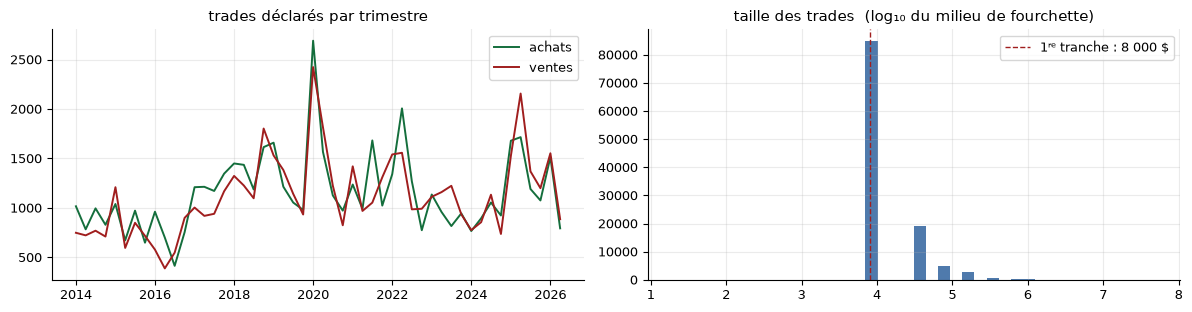

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
m = df.groupby([df.tau.dt.to_period("Q"), "op"]).size().unstack(fill_value=0)
m.index = m.index.to_timestamp()
ax[0].plot(m.index, m.get("buy", 0), color=VERT, lw=1.4, label="achats")
ax[0].plot(m.index, m.get("sell", 0), color=ROUGE, lw=1.4, label="ventes")
ax[0].set_title("trades déclarés par trimestre"); ax[0].legend()
ax[1].hist(np.log10(df.A.clip(lower=1)), bins=40, color=BLEU, alpha=.75)
ax[1].set_title("taille des trades  (log₁₀ du milieu de fourchette)")
ax[1].axvline(np.log10(8000.5), color=ROUGE, ls="--", lw=1, label="1ʳᵉ tranche : 8 000 $")
ax[1].legend(); plt.tight_layout(); plt.savefig(f"{FIGS}/flux.png", dpi=150, bbox_inches="tight"); plt.show()

## §2 — L'univers ticker $\mathcal{U}_t$

$$\mathcal{U}_t = \{\, i \;:\; \text{(a) action} \;\wedge\; \text{(b) } \exists\, u \in [\,n(t)-4,\; n(t)\,] \text{ tq } P_i(u) \text{ observée} \,\}$$

**(b) n'est pas une prudence, c'est une nécessité** : le cache prolonge les prix au dernier cours connu.
Sans ce test, une société morte en 2019 « cote » encore en 2026 — un cadavre à rendement 0 et risque 0.

In [8]:
NLAST  = {tk: cal.searchsorted(d, side="right") - 1 for tk, d in LAST.items()}   # dernier vrai cours
NFIRST = {tk: int(np.argmax(~np.isnan(PXV[tk]))) for tk in PXV}                  # premier cours disponible

def vivant(tk, i):
    # condition (b) : le titre cote DEJA (sa serie a commence) ET cote ENCORE (dernier cours <= 4 j)
    return NFIRST[tk] <= i and NLAST[tk] >= i - 4
mort = sum(1 for tk in PXV if NLAST[tk] < len(cal) - 5)
print(f"titres dont la cotation s'arrête avant la fin du calendrier : {mort:,} / {len(PXV):,} ({mort/len(PXV):.0%})")

titres dont la cotation s'arrête avant la fin du calendrier : 80 / 2,755 (3%)


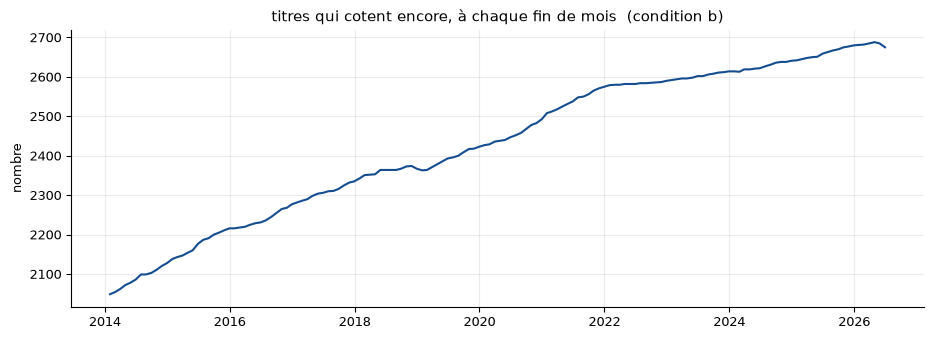

150 coupes mensuelles · 2014-01-31 → 2026-06-30


In [9]:
# les coupes commencent avec la donnée : premier mois de 2014, pas le début du calendrier de prix
DEBUT = pd.Timestamp("2014-01-31")
coupes = [cal.searchsorted(d, side="right") - 1
          for d in pd.date_range(DEBUT, cal[-1], freq="ME")]
coupes = sorted(set(i for i in coupes if W <= i < len(cal) - 1))
viv = [sum(vivant(tk, i) for tk in PXV) for i in coupes]
plt.plot([cal[i] for i in coupes], viv, color=BLEU, lw=1.5)
plt.title("titres qui cotent encore, à chaque fin de mois  (condition b)"); plt.ylabel("nombre"); plt.savefig(f"{FIGS}/univers.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"{len(coupes)} coupes mensuelles · {cal[coupes[0]].date()} → {cal[coupes[-1]].date()}")

## §3 — Le portefeuille des membres, pour dater les lots

Il **ne sert qu'à ça**. Par couple (membre, titre), file **FIFO** : un achat empile un lot
$(s_k,\, q_k)$ avec $q_k = A_k / P_{i_k}(s_k)$ ; une vente consomme les lots **les plus anciens**.

Chaque tranche $\ell$ consommée par la vente $k$ a été détenue
$$h_\ell \;=\; \#\bigl(\mathcal{C} \cap (\,s_\ell,\; s_k\,]\bigr) \quad \text{jours de bourse.}$$

In [10]:
def tranches_vendues(g):
    # pour chaque vente : la liste des (h, q) consommés, et la part non appariée
    lots, out = deque(), {}
    for idx, i0, op, A in zip(g.index.values, g.i0.values, g.op.values, g.A.values):
        p = PXV[g.tk.iat[0]][i0]
        if not np.isfinite(p) or p <= 0: continue
        q = A / p
        if op == "buy":
            lots.append([i0, q])
        else:
            reste, pieces = q, []
            while reste > 1e-12 and lots:
                s0, q0 = lots[0]
                pris = min(reste, q0); reste -= pris; lots[0][1] -= pris
                pieces.append((i0 - s0, pris))          # (h, q)
                if lots[0][1] <= 1e-12: lots.popleft()
            out[idx] = (pieces, reste)                  # reste = part non appariée
    return out

In [11]:
VENTES = {}
for (_, _), g in df.groupby(["bioguide_id","tk"], sort=False):
    VENTES.update(tranches_vendues(g))
n_v = (df.op == "sell").sum()
print(f"ventes traitées : {len(VENTES):,} / {n_v:,}")

ventes traitées : 55,061 / 55,924


### 3.1 Validation — un cas recalculé à la main, hors moteur

In [12]:
# on prend un membre×titre avec au moins 1 achat puis 1 vente
cand = (df.assign(b=(df.op=="buy").astype(int), s=(df.op=="sell").astype(int))
          .groupby(["bioguide_id","tk"])[["b","s"]].sum().query("b>=2 and s>=1"))
bid, tk = cand.index[0]
g = df[(df.bioguide_id == bid) & (df.tk == tk)]
print(f"{g.member_name.iat[0]} — {tk}")
display(g[["tau","op","A","i0"]])

# recalcul manuel
lots_m, res_m = [], {}
for idx, i0, op, A in zip(g.index, g.i0, g.op, g.A):
    q = A / PXV[tk][i0]
    if op == "buy": lots_m.append([i0, q])
    else:
        reste, pcs = q, []
        while reste > 1e-12 and lots_m:
            s0, q0 = lots_m[0]
            pris = min(reste, q0); reste -= pris; lots_m[0][1] -= pris
            pcs.append((i0 - s0, pris))
            if lots_m[0][1] <= 1e-12: lots_m.pop(0)
        res_m[idx] = (pcs, reste)
ok = all(np.allclose([x[0] for x in res_m[i][0]], [x[0] for x in VENTES[i][0]]) and
         np.allclose([x[1] for x in res_m[i][0]], [x[1] for x in VENTES[i][0]]) for i in res_m)
print(f"\n✅ recalcul manuel identique au moteur : {ok}")
for i in res_m: print(f"   vente {i} → tranches (h en jours, parts) : "
                      f"{[(int(h), round(q,2)) for h,q in res_m[i][0]]} · non apparié {res_m[i][1]:.2f}")

Richard W. Allen — ABT


,tau,op,A,i0
46306,2019-09-13,buy,32500.5,1936
46562,2019-09-27,buy,32500.5,1946
112088,2026-04-16,sell,32500.5,3591



✅ recalcul manuel identique au moteur : True
   vente 112088 → tranches (h en jours, parts) : [(1655, np.float64(340.43))] · non apparié 0.00


### 3.2 Les durées de détention observées

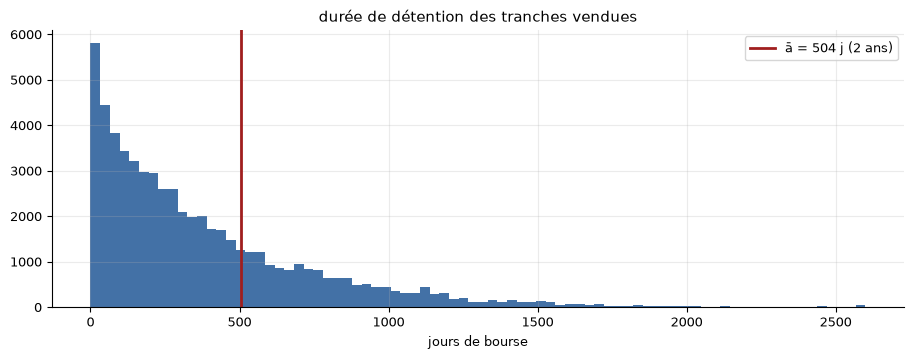

tranches vendues : 59,963 · médiane 268 j · part détenue > 2 ans : 27.3%


In [13]:
H = np.concatenate([[h for h, _ in p] for p, _ in VENTES.values() if p]) if VENTES else np.array([])
plt.hist(np.clip(H, 0, 2600), bins=80, color=BLEU, alpha=.8)
plt.axvline(A_BAR, color=ROUGE, lw=2, label=f"ā = {A_BAR} j (2 ans)")
plt.title("durée de détention des tranches vendues"); plt.xlabel("jours de bourse"); plt.legend(); plt.savefig(f"{FIGS}/durees.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"tranches vendues : {len(H):,} · médiane {np.median(H):.0f} j · "
      f"part détenue > 2 ans : {(H > A_BAR).mean():.1%}")

## §4 — La purge $\gamma$

$$\gamma_k \;=\; \frac{\sum_{\ell \subset k} \mathbf{1}\{h_\ell \le \bar a\}\, q_\ell}{\sum_{\ell \subset k} q_\ell}
\;\in\; [0,1]$$

= la part de la vente $k$ portant sur des lots détenus **moins de 2 ans**.

**achat $\Rightarrow \gamma_k = 1$** (un lot neuf n'a pas d'histoire) · **vente non appariée $\Rightarrow \gamma = 1$**
(on ne peut pas la dater, on ne l'invente pas vieille).

In [14]:
gam = np.ones(len(df))
for idx, (pieces, reste) in VENTES.items():
    tot = sum(q for _, q in pieces) + reste
    if tot <= 0: continue
    jeune = sum(q for h, q in pieces if h <= A_BAR) + reste     # le non apparié est conservé
    gam[idx] = jeune / tot
df["gamma"] = gam
v = df[df.op == "sell"]
print(f"ventes : γ = 1 (intactes) {100*(v.gamma > .999).mean():.1f}% · "
      f"γ = 0 (supprimées) {100*(v.gamma < .001).mean():.1f}% · "
      f"partielles {100*((v.gamma >= .001) & (v.gamma <= .999)).mean():.1f}%")
print(f"masse vendue conservée : {100*(v.A*v.gamma).sum()/v.A.sum():.1f}% des {v.A.sum()/1e9:.2f} Md$ déclarés")

ventes : γ = 1 (intactes) 79.9% · γ = 0 (supprimées) 17.1% · partielles 3.1%
masse vendue conservée : 89.5% des 2.11 Md$ déclarés


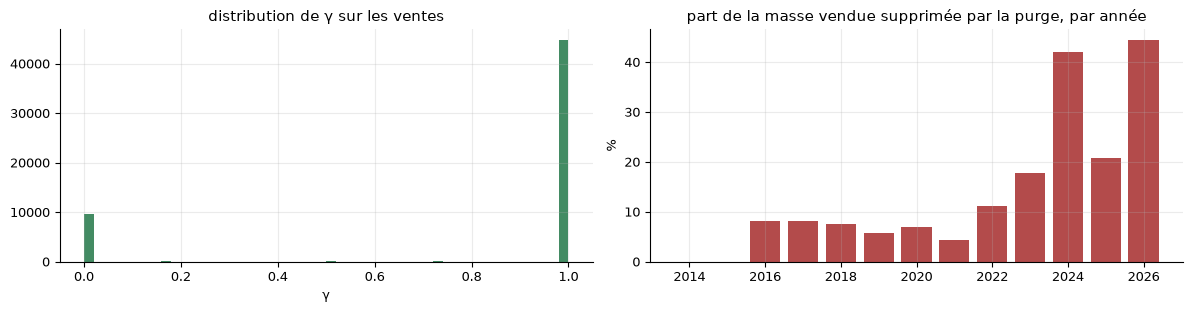

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].hist(v.gamma, bins=50, color=VERT, alpha=.8)
ax[0].set_title("distribution de γ sur les ventes"); ax[0].set_xlabel("γ")
part = v.assign(an=v.tau.dt.year).groupby("an").apply(lambda x: (x.A*x.gamma).sum()/x.A.sum())
ax[1].bar(part.index, 100*(1-part.values), color=ROUGE, alpha=.8)
ax[1].set_title("part de la masse vendue supprimée par la purge, par année"); ax[1].set_ylabel("%")
plt.tight_layout(); plt.savefig(f"{FIGS}/gamma.png", dpi=150, bbox_inches="tight"); plt.show()

## §5 — Le flux par ticker

$$\mathcal{K}_{i,t}(W) = \{\, k : i_k = i,\; t - W < s_k \le t \,\}$$
$$Buy_{i,t} = \!\!\sum_{k \in \mathcal{K}_{i,t}}\!\! A_k \mathbf{1}\{d_k = +1\}
\qquad
Sell^{\varphi}_{i,t} = \!\!\sum_{k \in \mathcal{K}_{i,t}}\!\! A_k\, \gamma_k\, \mathbf{1}\{d_k = -1\}$$
$$NetBuy^{\varphi}_{i,t} = \bigl[\, Buy_{i,t} - Sell^{\varphi}_{i,t} \,\bigr]^{+}
\qquad
nBuyers_{i,t} = \#\{\, m_k : k \in \mathcal{K}_{i,t},\; d_k = +1 \,\}$$

In [16]:
df["sgn"] = np.where(df.op == "buy", 1.0, -1.0)
df["Aeff"] = df.A * np.where(df.op == "buy", 1.0, df.gamma)     # A_k · γ_k pour les ventes
ordre = np.argsort(df.i0.values, kind="stable")
I0 = df.i0.values[ordre]
IW, ordreW = I0, ordre        # index de FENÊTRAGE — τ par défaut ; bascule sur δ au §11

def flux(i1, W=None):
    W = W or W_REF
    # le panel (Buy, Sell^phi, NetBuy^phi, nBuyers) a la coupe d'indice i1
    lo, hi = np.searchsorted(IW, i1 - W, "right"), np.searchsorted(IW, i1, "right")
    g = df.iloc[ordreW[lo:hi]]
    if not len(g): return pd.DataFrame(columns=["Buy","Sell","NetBuy","nBuyers"])
    buy, sell = g[g.op == "buy"], g[g.op == "sell"]
    sell_r = sell[sell.gamma > 0]                                    # ventes de stock récent (γ>0)
    p = pd.DataFrame({"Buy":     buy.groupby("tk").A.sum(),
                      "Sell":    sell.groupby("tk").Aeff.sum(),      # Aeff = A·γ (purgé)
                      "nBuyers": buy.groupby("tk").bioguide_id.nunique(),
                      "nSellers":sell_r.groupby("tk").bioguide_id.nunique()}).fillna(0.0)
    p["NetBuy"] = (p.Buy - p.Sell).clip(lower=0)                     # long : partie positive
    p["Net"]    = p.Buy - p.Sell                                     # signé : peut être < 0
    return p[["Buy","Sell","NetBuy","Net","nBuyers","nSellers"]]

In [17]:
i_demo = coupes[len(coupes)//2]
P_demo = flux(i_demo)
print(f"coupe du {cal[i_demo].date()} — {len(P_demo)} titres touchés sur la fenêtre de {W} j")
P_demo.sort_values("NetBuy", ascending=False).head(8).round(0)

coupe du 2020-04-30 — 604 titres touchés sur la fenêtre de 21 j


,Buy,Sell,NetBuy,Net,nBuyers,nSellers
tk,,,,,,
AVY,350001.0,8000.0,342000.0,342000.0,1.0,1.0
TRS,207501.0,0.0,207501.0,207501.0,1.0,0.0
WTM,207501.0,0.0,207501.0,207501.0,1.0,0.0
G,207501.0,0.0,207501.0,207501.0,1.0,0.0
CSL,207501.0,0.0,207501.0,207501.0,1.0,0.0
SWK,215002.0,16001.0,199001.0,199001.0,1.0,2.0
AMZN,279504.0,99002.0,180502.0,180502.0,7.0,4.0
ALGN,175000.0,8000.0,167000.0,167000.0,1.0,1.0


## §6 — Le signal

$$S_t = \{\, i \in \mathcal{U}_t \;:\; NetBuy^{\varphi}_{i,t} > 0 \;\wedge\; nBuyers_{i,t} \ge b_{\min} = 2 \,\}$$

In [18]:
def selection(i1, W=None):
    p = flux(i1, W)
    if not len(p): return []
    ok = (p.NetBuy > 0) & (p.nBuyers >= B_MIN)
    return [tk for tk in p.index[ok] if vivant(tk, i1)]

SEL = {i: selection(i) for i in coupes}
taille = np.array([len(SEL[i]) for i in coupes])
print(f"|S_t| : médiane {np.median(taille):.0f} · q25 {np.percentile(taille,25):.0f} · "
      f"q75 {np.percentile(taille,75):.0f} · min {taille.min()} · max {taille.max()}")
print(f"mois où |S_t| = 0 : {(taille==0).sum()} · où |S_t| < 5 : {(taille<5).sum()} / {len(taille)}")

|S_t| : médiane 28 · q25 19 · q75 44 · min 1 · max 123
mois où |S_t| = 0 : 0 · où |S_t| < 5 : 2 / 150


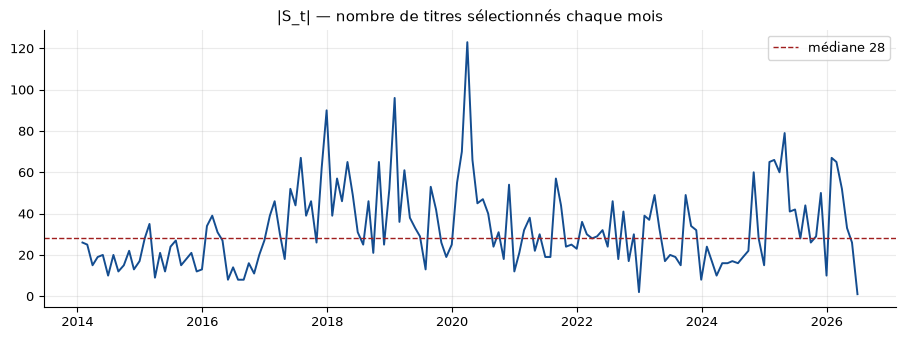

In [19]:
plt.plot([cal[i] for i in coupes], taille, color=BLEU, lw=1.4)
plt.axhline(np.median(taille), color=ROUGE, ls="--", lw=1, label=f"médiane {np.median(taille):.0f}")
plt.title("|S_t| — nombre de titres sélectionnés chaque mois"); plt.legend(); plt.savefig(f"{FIGS}/selection.png", dpi=150, bbox_inches="tight"); plt.show()

In [20]:
print(f"exemple — la sélection du {cal[i_demo].date()} ({len(SEL[i_demo])} titres) :")
P_demo.loc[SEL[i_demo]].sort_values("NetBuy", ascending=False).head(10).round(0)

exemple — la sélection du 2020-04-30 (66 titres) :


,Buy,Sell,NetBuy,Net,nBuyers,nSellers
tk,,,,,,
AMZN,279504.0,99002.0,180502.0,180502.0,7.0,4.0
AON,115502.0,0.0,115502.0,115502.0,2.0,0.0
RHI,115502.0,7733.0,107769.0,107769.0,2.0,1.0
SHEL,91002.0,0.0,91002.0,91002.0,3.0,0.0
RIO,91002.0,0.0,91002.0,91002.0,2.0,0.0
SONY,97003.0,8000.0,89002.0,89002.0,2.0,1.0
VMC,83001.0,0.0,83001.0,83001.0,2.0,0.0
NFLX,123502.0,40501.0,83001.0,83001.0,3.0,2.0
SBGSY,83001.0,0.0,83001.0,83001.0,2.0,0.0


### 6.1 Qui a acheté quoi — la table $B_{m,t}$

Pour pondérer par membre (\S7) il faut, à chaque coupe, **qui** a acheté **quels** titres de $S_t$ :
$$\mathcal{M}_t = \{\, m : m \text{ a acheté au moins un titre de } S_t \,\}, \qquad K_t = |\mathcal{M}_t|$$
$$B_{m,t} = \{\, i \in S_t : m \text{ a acheté } i \text{ dans la fenêtre} \,\}$$

In [21]:
def acheteurs(i1, S, W=None):
    W = W or W_REF
    # rend {membre: [ses tickers de S]} sur la fenêtre de la coupe i1
    if not S: return {}
    lo, hi = np.searchsorted(IW, i1 - W, "right"), np.searchsorted(IW, i1, "right")
    g = df.iloc[ordreW[lo:hi]]
    g = g[(g.op == "buy") & (g.tk.isin(set(S)))]
    return {m: sorted(set(x)) for m, x in g.groupby("bioguide_id").tk}

ACH = {i: acheteurs(i, SEL[i]) for i in coupes}
K = np.array([len(ACH[i]) for i in coupes])
print(f"K_t (membres acheteurs) : médiane {np.median(K):.0f} · q25 {np.percentile(K,25):.0f} · "
      f"q75 {np.percentile(K,75):.0f} · min {K.min()} · max {K.max()}")
nB = np.array([len(v) for i in coupes for v in ACH[i].values()])
print(f"|B_m| (titres par membre) : médiane {np.median(nB):.0f} · q90 {np.percentile(nB,90):.0f} · max {nB.max()}")

K_t (membres acheteurs) : médiane 20 · q25 15 · q75 25 · min 2 · max 45
|B_m| (titres par membre) : médiane 2 · q90 8 · max 96


In [22]:
a = ACH[i_demo]
print(f"coupe du {cal[i_demo].date()} — {len(a)} membres acheteurs, {len(SEL[i_demo])} titres retenus\n")
apercu = pd.DataFrame([{"membre": df.loc[df.bioguide_id == m, "member_name"].iat[0],
                        "|B_m|": len(v), "poids par titre": 1/(len(a)*len(v)), "ses titres": ", ".join(v[:5])}
                       for m, v in list(a.items())[:8]])
apercu.round(4)

coupe du 2020-04-30 — 27 membres acheteurs, 66 titres retenus



,membre,|B_m|,poids par titre,ses titres
0,Cindy Axne,1,0.0370,MA
1,Mo Brooks,2,0.0185,"D, DUK"
2,Susan W. Brooks,3,0.0123,"AMZN, MA, QCOM"
3,James E. Banks,1,0.0370,SBUX
4,Thomas R Carper,4,0.0093,"DGX, LHX, QCOM, SBUX"
5,K. Michael Conaway,2,0.0185,"AMZN, DUK"
6,Katherine M. Clark,2,0.0185,"LHX, MOS"
7,Gilbert Cisneros,11,0.0034,"AON, GE, HQY, LHX, LUMN"


## §7 — Le portefeuille : **une voix par membre**

Chaque membre acheteur reçoit $1/K_t$ du capital, puis **répartit sa part également** entre les titres
qu'il a achetés :
$$\boxed{\;w_{i,t} \;=\; \frac{1}{K_t} \sum_{m \in \mathcal{M}_t} \frac{\mathbf{1}\{i \in B_{m,t}\}}{|B_{m,t}|}\;}$$

**Pourquoi ce poids.** Le montant $A_k$ n'y apparaît pas : les 11 M\$ d'un élu fortuné et les 15 k\$ d'un
autre pèsent **exactement $1/K$ chacun**. Le portefeuille cesse d'être piloté par la richesse.

**Trois propriétés, aucun paramètre :**
- $\sum_i w_{i,t} = \frac{1}{K}\sum_m \sum_{i \in B_m} \frac{1}{|B_m|} = \frac{1}{K}\sum_m 1 = 1$ — normalisation automatique
- $|B_m| = 1\ \forall m \Rightarrow w_i \propto b_i$ ; $\;|B_m| = |S_t|\ \forall m \Rightarrow w_i = 1/|S_t|$ (l'équipondéré)
  $\Rightarrow$ la règle se place **seule** entre les deux régimes
- un rééquilibrage de trust sur 133 lignes donne $1/(133K)$ par ligne $\Rightarrow$ **la délégation se dilue toute seule**

**À la coupe** $t_R$, exécution au close du jour suivant, puis buy-and-hold :
$$nbr_i = \frac{V(t_R{+}1)\, w_{i,t_R}}{P_i(t_R{+}1)}, \qquad
V(t) = \sum_{i} nbr_i\, P_i(t), \qquad r(t) = \frac{V(t)}{V(t-1)} - 1$$

In [23]:
def poids(i1, W=None, sel=None, ach=None):
    # w_i = (1/K) * somme_m 1{i dans B_m} / |B_m|   — restreint aux titres priçables à l'exécution
    S = [tk for tk in (sel if sel is not None else SEL[i1]) if np.isfinite(PXV[tk][i1 + 1])]
    if not S: return {}
    Sset = set(S)
    A = ach if ach is not None else ACH[i1]
    B = {m: [tk for tk in v if tk in Sset] for m, v in A.items()}
    B = {m: v for m, v in B.items() if v}
    if not B: return {}
    Kt = len(B)
    w = {}
    for m, v in B.items():
        part = 1.0 / (Kt * len(v))
        for tk in v: w[tk] = w.get(tk, 0.0) + part
    assert abs(sum(w.values()) - 1.0) < 1e-12, f"les poids ne somment pas à 1 : {sum(w.values())}"
    return w

WPO = {i: poids(i) for i in coupes[:-1]}
mx = np.array([max(v.values()) for v in WPO.values() if v])
print(f"poids max par mois : médiane {np.median(mx):.1%} · q90 {np.percentile(mx,90):.1%} · max {mx.max():.1%}")
print(f"mois où une ligne dépasse 10 % : {(mx > .10).sum()} / {len(mx)}  ({(mx > .10).mean():.0%})")

poids max par mois : médiane 11.0% · q90 18.1% · max 50.0%
mois où une ligne dépasse 10 % : 86 / 149  (58%)


In [24]:
def run():
    V = np.full(len(cal), np.nan); nbr = {}
    e0 = coupes[0] + 1
    V[e0] = 100.0
    bornes = [(coupes[j] + 1, coupes[j+1] + 1) for j in range(len(coupes) - 1)]
    for (e, e_next) in bornes:
        w = WPO.get(e - 1, {})                                       # poids « une voix par membre »
        nbr = {tk: V[e] * wi / PXV[tk][e] for tk, wi in w.items()}
        for t in range(e + 1, min(e_next, len(cal) - 1) + 1):
            V[t] = sum(q * PXV[tk][t] for tk, q in nbr.items()) if nbr else V[t - 1]
    out = pd.Series(V, index=cal)
    span = out.loc[out.first_valid_index():out.last_valid_index()]
    assert span.notna().all(), f"trous dans la NAV : {span.isna().sum()} jours"
    return span

V = run()
r = V.pct_change().dropna()
V_ref, r_ref, mx_ref, tail_ref = V.copy(), r.copy(), mx.copy(), taille.copy()   # référence W = 21
print(f"série : {V.index[0].date()} → {V.index[-1].date()} · {len(r):,} jours · NAV finale {V.iloc[-1]:.1f}")

série : 2014-02-03 → 2026-07-01 · 3,120 jours · NAV finale 554.3


### 7.1 Vérification des deux régimes limites (propriété P2)

La formule doit redonner **$w \propto b_i$** si chaque membre n'achète qu'un titre, et **$1/|S_t|$** si
tous achètent tout. On le vérifie numériquement, sur une coupe réelle.

In [25]:
i1 = i_demo; S = [tk for tk in SEL[i1] if np.isfinite(PXV[tk][i1+1])]; Sset = set(S)
B0 = {m: [tk for tk in v if tk in Sset] for m, v in ACH[i1].items()}
B0 = {m: v for m, v in B0.items() if v}

def w_de(B):
    Kt = len(B); w = {}
    for m, v in B.items():
        for tk in v: w[tk] = w.get(tk, 0.0) + 1.0/(Kt*len(v))
    return w

# régime 1 : chaque membre n'achète qu'un titre  →  w ∝ b_i
B1 = {m: [v[0]] for m, v in B0.items()}
w1 = w_de(B1)
b1 = pd.Series({tk: sum(1 for v in B1.values() if tk in v) for tk in w1})
ok1 = np.allclose(pd.Series(w1)[b1.index].values, (b1/b1.sum()).values)

# régime 2 : tous les membres achètent tous les titres  →  w = 1/|S|
B2 = {m: S for m in B0}
w2 = w_de(B2)
ok2 = np.allclose(list(w2.values()), 1.0/len(S))

print(f"régime |B_m| = 1     →  w ∝ b_i      : {ok1}")
print(f"régime B_m = S_t     →  w = 1/|S_t|  : {ok2}   (1/{len(S)} = {1/len(S):.5f})")
assert ok1 and ok2
print("\n✅ la formule niche bien les deux régimes — sans paramètre")

régime |B_m| = 1     →  w ∝ b_i      : True
régime B_m = S_t     →  w = 1/|S_t|  : True   (1/66 = 0.01515)

✅ la formule niche bien les deux régimes — sans paramètre


### 7.2 Ce que la pondération change, concrètement

In [26]:
w_reel = WPO[i_demo]
w_eq = 1/len(w_reel)
cmp = (pd.Series(w_reel).sort_values(ascending=False).to_frame("w (une voix/membre)")
         .assign(**{"w équipondéré": w_eq}))
cmp["rapport"] = cmp.iloc[:,0] / w_eq
print(f"coupe du {cal[i_demo].date()} · {len(w_reel)} titres · équipondéré = {w_eq:.4f}")
cmp.head(8).round(4)

coupe du 2020-04-30 · 66 titres · équipondéré = 0.0152


,w (une voix/membre),w équipondéré,rapport
SBUX,0.0795,0.0152,5.2489
MA,0.0664,0.0152,4.3796
AMZN,0.0533,0.0152,3.5163
ADBE,0.0463,0.0152,3.0556
CINF,0.0407,0.0152,2.6889
TMUS,0.0404,0.0152,2.6667
VSAT,0.0394,0.0152,2.5972
PINS,0.0381,0.0152,2.5163


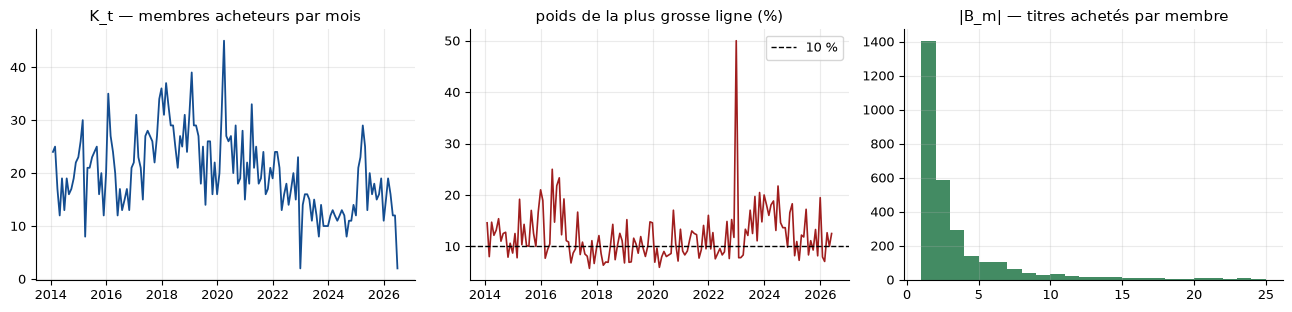

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].plot([cal[i] for i in coupes], K, color=BLEU, lw=1.3)
ax[0].set_title("K_t — membres acheteurs par mois")
ax[1].plot([cal[i] for i in coupes[:-1]], 100*mx, color=ROUGE, lw=1.2)
ax[1].axhline(10, color="k", ls="--", lw=1, label="10 %"); ax[1].legend()
ax[1].set_title("poids de la plus grosse ligne (%)")
ax[2].hist(nB, bins=range(1, 26), color=VERT, alpha=.8)
ax[2].set_title("|B_m| — titres achetés par membre")
plt.tight_layout(); plt.savefig(f"{FIGS}/poids.png", dpi=150, bbox_inches="tight"); plt.show()

### 7.3 Choisir $W$ — sur la **concentration**, jamais sur le rendement

Avec $W = 21$ j, une ligne dépasse 10 % du portefeuille dans **58 %** des mois (max 50 %) : $K_t$ est trop
petit (médiane 20, minimum 2). On desserre la seule constante qui pilote mécaniquement $K_t$ et $|S_t|$.

**Le critère est annoncé avant de calculer quoi que ce soit sur les rendements :**

$$W^\star \;=\; \min\Bigl\{\, W \in \{21, 42, 63, 126\} \;:\; \mathbb{P}\bigl[\max_i w_{i,t} > 10\,\%\bigr] \le 20\,\% \,\Bigr\}$$

Aucun rendement n'entre dans ce choix — c'est ce qui empêche le balayage de devenir une pêche au résultat.

In [28]:
lignes = []
for Wc in [21, 42, 63, 126]:
    Sc  = {i: selection(i, Wc) for i in coupes}
    Ac  = {i: acheteurs(i, Sc[i], Wc) for i in coupes}
    Wc_ = {i: poids(i, Wc, Sc[i], Ac[i]) for i in coupes[:-1]}
    mxc = np.array([max(v.values()) for v in Wc_.values() if v])
    lignes.append({"W (j)": Wc,
                   "|S_t| médian": int(np.median([len(Sc[i]) for i in coupes])),
                   "K_t médian":   int(np.median([len(Ac[i]) for i in coupes])),
                   "poids max médian": np.median(mxc),
                   "part mois > 10 %": (mxc > .10).mean()})
tabW = pd.DataFrame(lignes).set_index("W (j)")
ok = tabW[tabW["part mois > 10 %"] <= .20]
W_STAR = int(ok.index[0]) if len(ok) else int(tabW["part mois > 10 %"].idxmin())
print(tabW.assign(**{"poids max médian": (100*tabW["poids max médian"]).round(1).astype(str)+" %",
                     "part mois > 10 %": (100*tabW["part mois > 10 %"]).round(0).astype(int).astype(str)+" %"}).to_string())
print(f"\n→ W* = {W_STAR} j" + ("" if len(ok) else "  (aucun ne passe le critère : on prend le moins concentré, et on le dit)"))

       |S_t| médian  K_t médian poids max médian part mois > 10 %
W (j)                                                            
21               28          19           11.0 %             58 %
42               64          32            7.2 %             17 %
63               91          39            6.3 %              9 %
126             156          53            5.4 %              5 %

→ W* = 42 j


In [29]:
W = W_STAR                                          # on rejoue toute la chaîne avec W*
SEL = {i: selection(i, W) for i in coupes}
ACH = {i: acheteurs(i, SEL[i], W) for i in coupes}
WPO = {i: poids(i, W, SEL[i], ACH[i]) for i in coupes[:-1]}
taille = np.array([len(SEL[i]) for i in coupes]); K = np.array([len(ACH[i]) for i in coupes])
mx = np.array([max(v.values()) for v in WPO.values() if v])
V = run(); r = V.pct_change().dropna()
print(f"W = {W} j · |S_t| médian {np.median(taille):.0f} · K_t médian {np.median(K):.0f} · "
      f"poids max médian {np.median(mx):.1%} · mois > 10 % : {(mx>.10).mean():.0%}")
print(f"NAV finale {V.iloc[-1]:.1f}")

W = 42 j · |S_t| médian 64 · K_t médian 32 · poids max médian 7.2% · mois > 10 % : 17%
NAV finale 622.1


### 7.4 Validation — un mois recalculé à la main

In [30]:
j = len(coupes)//2
e, e_next = coupes[j] + 1, coupes[j+1] + 1
w = WPO[e-1]
nbr_m = {tk: V.loc[cal[e]] * wi / PXV[tk][e] for tk, wi in w.items()}
t_test = min(e + 5, e_next)
V_main = sum(q * PXV[tk][t_test] for tk, q in nbr_m.items())
print(f"segment du {cal[e].date()} · {len(w)} titres · Σw = {sum(w.values()):.10f} · "
      f"poids min {min(w.values()):.4f} / max {max(w.values()):.4f}")
print(f"V({cal[t_test].date()})  moteur {V.loc[cal[t_test]]:.4f}   à la main {V_main:.4f}   "
      f"écart {abs(V.loc[cal[t_test]] - V_main):.2e}")
assert abs(V.loc[cal[t_test]] - V_main) < 1e-8
print("✅ identique")

segment du 2020-05-01 · 146 titres · Σw = 1.0000000000 · poids min 0.0006 / max 0.0573
V(2020-05-08)  moteur 197.9369   à la main 197.9369   écart 0.00e+00
✅ identique


## §8 — Le résultat

Deux runs côte à côte : la fenêtre de référence $W = 21$ j, et $W^\star$ retenu par le critère de
concentration. **Ce sont deux essais déclarés**, pas deux chances de trouver un gagnant.

In [31]:
def bilan(Vx, nom):
    rx = Vx.pct_change().dropna()
    ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                       "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
    xx = (ax.s - ax.m).values
    dd = pd.DataFrame({"p": rx, "m": r_spy.reindex(rx.index)}).join(
             pd.read_csv(f"{RACINE}/00. S3S4 en cours/cache/ff_factors.csv",
                         parse_dates=["Date"]).set_index("Date")[["RF"]]).dropna()
    yy, XX = (dd.p - dd.RF).values, (dd.m - dd.RF).values
    b, a = np.polyfit(XX, yy, 1); ee = yy - (a + b*XX)
    return {"run": nom, "excès %/an": 100*xx.mean(), "t": xx.mean()/(xx.std(ddof=1)/np.sqrt(len(xx))),
            "α %/an": 252*a*100, "t_α": a/(ee.std(ddof=2)/np.sqrt(len(yy))), "β": b,
            "NAV": Vx.iloc[-1], "ann. gagnantes": f"{int((xx>0).sum())}/{len(xx)}"}

pd.DataFrame([bilan(V_ref, f"W = {W_REF} j (référence)"), bilan(V, f"W* = {W} j")]).set_index("run").round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
W = 21 j (référence),0.303,0.165,0.059,0.029,1.038,554.284,7/13
W* = 42 j,1.706,1.030,1.048,0.645,1.023,622.132,7/13


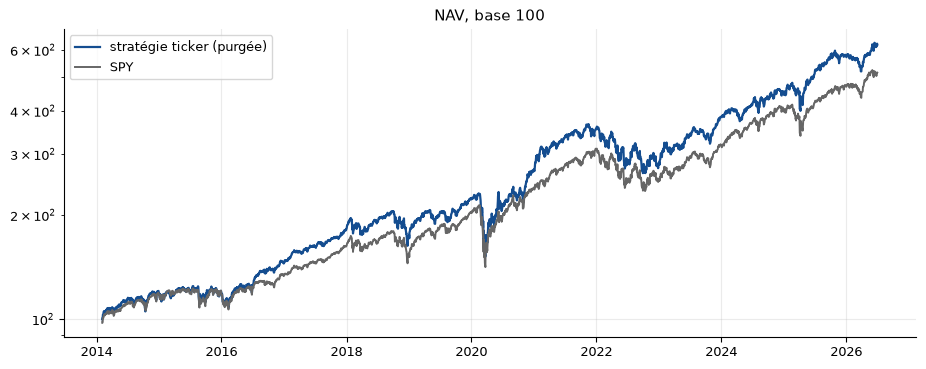

stratégie 622   ·   SPY 517


In [32]:
nav_spy = (1 + r_spy.reindex(V.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(V.index, V, color=BLEU, lw=1.6, label="stratégie ticker (purgée)")
ax.plot(nav_spy.index, nav_spy, color=GRIS, lw=1.4, label="SPY")
ax.set_yscale("log"); ax.set_title("NAV, base 100"); ax.legend(); plt.savefig(f"{FIGS}/nav.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"stratégie {V.iloc[-1]:.0f}   ·   SPY {nav_spy.iloc[-1]:.0f}")

In [33]:
def compose(s): return float((1 + s).prod() - 1)
an = pd.DataFrame({"strat": r.groupby(r.index.year).apply(compose),
                   "spy":   r_spy.reindex(r.index).fillna(0).groupby(r.index.year).apply(compose)})
an["exces"] = an.strat - an.spy
x = an.exces.values
t_x = x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))
print(f"excès moyen {100*x.mean():+.2f} %/an · t = {t_x:+.2f} · "
      f"années gagnantes {(x>0).sum()}/{len(x)} · seuil t_{len(x)-1} ≈ 1,8")
(100*an).round(1)

excès moyen +1.71 %/an · t = +1.03 · années gagnantes 7/13 · seuil t_12 ≈ 1,8


,strat,spy,exces
Date,,,
2014,19.0,20.3,-1.3
2015,0.4,1.2,-0.9
2016,21.4,12.0,9.4
2017,24.7,21.7,3.0
2018,-3.7,-4.6,0.9
2019,27.9,31.2,-3.4
2020,21.8,18.3,3.5
2021,30.7,28.7,2.0
2022,-21.2,-18.2,-3.1


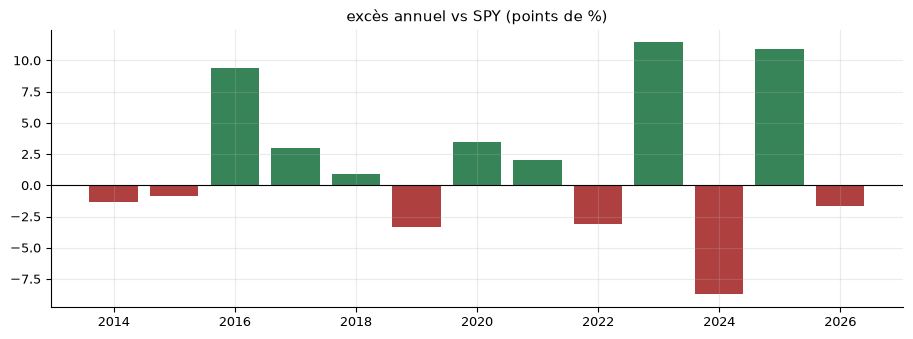

In [34]:
plt.bar(an.index, 100*an.exces, color=[VERT if v > 0 else ROUGE for v in an.exces], alpha=.85)
plt.axhline(0, color="k", lw=.8); plt.title("excès annuel vs SPY (points de %)"); plt.savefig(f"{FIGS}/exces.png", dpi=150, bbox_inches="tight"); plt.show()

In [35]:
ff = pd.read_csv(f"{RACINE}/00. S3S4 en cours/cache/ff_factors.csv", parse_dates=["Date"]).set_index("Date")
d = pd.DataFrame({"p": r, "m": r_spy.reindex(r.index)}).join(ff[["RF"]]).dropna()
y, X = (d.p - d.RF).values, (d.m - d.RF).values
beta, alpha = np.polyfit(X, y, 1)
eps = y - (alpha + beta*X); se = eps.std(ddof=2)
print(f"β = {beta:.3f}   α = {252*alpha*100:+.2f} %/an   "
      f"t_α = {alpha/(se/np.sqrt(len(y))):+.2f}   (marché en excès du taux sans risque)")

β = 1.023   α = +1.05 %/an   t_α = +0.64   (marché en excès du taux sans risque)


## §9 — Diagnostics

ADV des titres sélectionnés — médiane 102 M$/j · part sous 5 M$/j : 5.7%


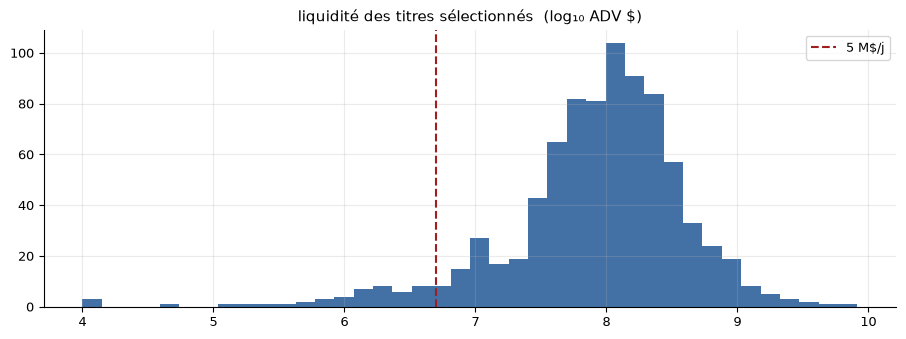

In [36]:
med_adv = {}
for tk in {t for S in SEL.values() for t in S}:
    f = f"{VOL}/{tk}.csv"
    if os.path.exists(f):
        try:
            v = pd.read_csv(f)
            med_adv[tk] = float((v.close_raw * v.volume).median())
        except Exception: pass
adv = pd.Series({tk: med_adv.get(tk, np.nan) for S in SEL.values() for tk in S}).dropna()
print(f"ADV des titres sélectionnés — médiane {adv.median()/1e6:,.0f} M$/j · "
      f"part sous 5 M$/j : {(adv < 5e6).mean():.1%}")
plt.hist(np.log10(adv.clip(lower=1e4)), bins=40, color=BLEU, alpha=.8)
plt.axvline(np.log10(5e6), color=ROUGE, ls="--", label="5 M$/j")
plt.title("liquidité des titres sélectionnés  (log₁₀ ADV $)"); plt.legend(); plt.savefig(f"{FIGS}/adv.png", dpi=150, bbox_inches="tight"); plt.show()

## §10 — Deux extensions : le cap de turnover et la jambe short

Deux ajouts, chacun **niche** l'existant (un réglage neutre redonne le long-only sans cap) :

**(a) Cap de turnover** — on ne réalloue pas d'un coup, on avance *partiellement* vers la cible, d'au plus
$\tau_{\max} = 25\,\%$ par mois :
$$\mathrm{TO}_R = \tfrac12 \sum_i |w^{\mathrm{cible}}_i - w^{\mathrm{d\acute erive}}_i|,\quad
\lambda_R = \min\!\Bigl(1, \tfrac{\tau_{\max}}{\mathrm{TO}_R}\Bigr),\quad
w^{\mathrm{r\acute ealis\acute e}}_i = w^{\mathrm{d\acute erive}}_i + \lambda_R\,(w^{\mathrm{cible}}_i - w^{\mathrm{d\acute erive}}_i)$$

**(b) Jambe short** — au lieu de couper à zéro, on garde aussi les titres à flux net **négatif** :
$$S^-_t = \{\, i \in \mathcal U_t : \mathrm{Net}^\varphi_{i,t} < 0 \;\wedge\; nSellers_{i,t} \ge 2 \,\},\qquad
r(t) = r^+(t) - \theta\, r^-(t)$$
$\theta = 0$ redonne le long-only ; $\theta = 1$ = long-short dollar-neutre. *(nSellers ne compte que les vendeurs de stock récent — la purge évite qu'un déstockage de vieux déclenche un short.)*

In [37]:
TAU_MAX = 0.25                                                        # turnover max par mois

def cap_turnover(w_der, w_cible, tau_max):
    keys = set(w_der) | set(w_cible)
    TO = 0.5 * sum(abs(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys)
    if TO <= 1e-12: return dict(w_cible)
    lam = min(1.0, tau_max / TO)
    return {k: w_der.get(k,0.0) + lam*(w_cible.get(k,0.0) - w_der.get(k,0.0)) for k in keys}

def run_livre(WP, tau_max=np.inf, cuts=None):
    # moteur d'UN livre (long ou short) : parts, buy-and-hold, cap de turnover. Rend (NAV, turnovers réalisés)
    # cuts=None → coupes mensuelles (défaut, non-régression) ; on peut passer des coupes hebdo (§14, Quiver)
    cuts = coupes if cuts is None else cuts
    V = np.full(len(cal), np.nan); nbr = {}; turns = []
    e0 = cuts[0] + 1; V[e0] = 100.0
    bornes = [(cuts[j] + 1, cuts[j+1] + 1) for j in range(len(cuts) - 1)]
    for (e, e_next) in bornes:
        w_cible = {tk: wi for tk, wi in WP.get(e-1, {}).items() if np.isfinite(PXV[tk][e])}
        val = sum(q*PXV[tk][e] for tk, q in nbr.items())
        w_der = {tk: q*PXV[tk][e]/val for tk, q in nbr.items()} if val > 0 else {}
        # Deux cas exemptés du cap, pour ne JAMAIS vaporiser du cash de la NAV :
        #  - w_der vide (1er déploiement) : on bâtit le livre en entier — partir du cash n'est pas de la rotation
        #    (sinon la NAV chutait à ~50 dès le 1er mois — artefact repéré par Alice sur la courbe B) ;
        #  - w_cible vide (sélection vide) : on sort tout au cash, tenu à plat (V[t]=V[t-1]), comme le run non capé.
        w_real = dict(w_cible) if (not w_der or not w_cible) else cap_turnover(w_der, w_cible, tau_max)
        # garde-fou bruyant : quand une cible existe, le livre reste pleinement investi (Σw=1) — pas de fuite
        assert (not w_cible) or abs(sum(w_real.values()) - 1.0) < 1e-6, "run_livre : poids capés ne somment pas à 1 (fuite de cash)"
        turns.append(0.5*sum(abs(w_real.get(k,0)-w_der.get(k,0)) for k in set(w_real)|set(w_der)))
        nbr = {tk: V[e]*wi/PXV[tk][e] for tk, wi in w_real.items() if abs(wi) > 1e-12}
        for t in range(e+1, min(e_next, len(cal)-1)+1):
            V[t] = sum(q*PXV[tk][t] for tk, q in nbr.items()) if nbr else V[t-1]
    span = pd.Series(V, index=cal); span = span.loc[span.first_valid_index():span.last_valid_index()]
    return span, np.array(turns[1:])                                 # turnover hors 1er déploiement

In [38]:
# NON-RÉGRESSION : run_livre(WPO, ∞) doit reproduire le long-only validé (§7)
span_ref, _ = run_livre(WPO, np.inf)
assert np.allclose(span_ref.values, V.reindex(span_ref.index).values, atol=1e-9), "run_livre casse la non-régression"
print(f"✅ non-régression : run_livre(WPO, ∞) ≡ le run §7  (NAV {span_ref.iloc[-1]:.1f})")

✅ non-régression : run_livre(WPO, ∞) ≡ le run §7  (NAV 622.1)


In [39]:
# le livre SHORT : titres net vendus, corroborés par ≥2 vendeurs de stock récent
def selection_short(i1, W):
    p = flux(i1, W)
    if not len(p): return []
    ok = (p.Net < 0) & (p.nSellers >= B_MIN)
    return [tk for tk in p.index[ok] if vivant(tk, i1)]

def vendeurs(i1, S, W):                                              # membres qui ont VENDU (γ>0) un titre de S
    if not S: return {}
    lo, hi = np.searchsorted(IW, i1 - W, "right"), np.searchsorted(IW, i1, "right")
    g = df.iloc[ordreW[lo:hi]]
    g = g[(g.op == "sell") & (g.gamma > 0) & (g.tk.isin(set(S)))]
    return {m: sorted(set(x)) for m, x in g.groupby("bioguide_id").tk}

SEL_S = {i: selection_short(i, W) for i in coupes}
ACH_S = {i: vendeurs(i, SEL_S[i], W) for i in coupes}
WPO_S = {i: poids(i, W, SEL_S[i], ACH_S[i]) for i in coupes[:-1]}
tS = np.array([len(SEL_S[i]) for i in coupes])
print(f"livre short — |S⁻_t| médian {np.median(tS):.0f} · q25 {np.percentile(tS,25):.0f} · q75 {np.percentile(tS,75):.0f} · "
      f"mois vides {(tS==0).sum()}/{len(tS)}")

livre short — |S⁻_t| médian 45 · q25 30 · q75 65 · mois vides 0/150


In [40]:
# les trois runs : A long sans cap (référence) · B long capé · C long-short capé
spanA, tA  = run_livre(WPO,   np.inf)
spanB, tB  = run_livre(WPO,   TAU_MAX)
spanS, tSt = run_livre(WPO_S, TAU_MAX)
rB = spanB.pct_change(); rS = spanS.pct_change()
idx = rB.index.intersection(rS.index)
rC = (rB.reindex(idx).fillna(0) - 1.0*rS.reindex(idx).fillna(0))     # θ = 1 : long capé − short capé
spanC = 100*(1+rC).cumprod()
print(f"turnover NON capé (long, référence) : médiane {np.median(tA):.1%}  ← ce que le cap ramène à 25 %")
print(f"turnover réalisé/mois — long capé : médiane {np.median(tB):.1%} · short capé : médiane {np.median(tSt):.1%}")

turnover NON capé (long, référence) : médiane 59.2%  ← ce que le cap ramène à 25 %
turnover réalisé/mois — long capé : médiane 25.0% · short capé : médiane 25.0%


In [41]:
tab = pd.DataFrame([bilan(spanA, "A · long, sans cap (référence)"),
                    bilan(spanB, "B · long, cap 25 %"),
                    bilan(spanC, "C · long-short (θ=1), cap 25 %")]).set_index("run")
tab.round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
"A · long, sans cap (référence)",1.706,1.030,1.048,0.645,1.023,622.132,7/13
"B · long, cap 25 %",0.269,0.233,-0.158,-0.116,1.014,530.993,6/13
"C · long-short (θ=1), cap 25 %",-12.801,-3.192,-0.253,-0.164,-0.016,122.424,3/13


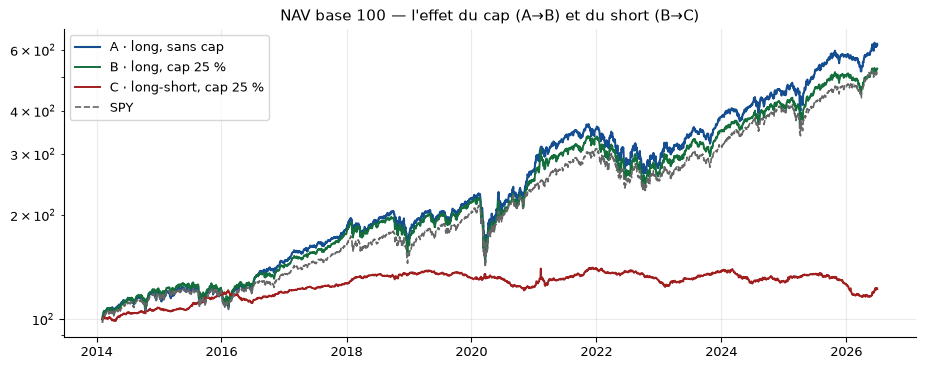

In [42]:
nav_spy2 = (1 + r_spy.reindex(spanA.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spanA.index, spanA, color=BLEU,  lw=1.5, label="A · long, sans cap")
ax.plot(spanB.index, spanB, color=VERT,  lw=1.4, label="B · long, cap 25 %")
ax.plot(spanC.index, spanC, color=ROUGE, lw=1.4, label="C · long-short, cap 25 %")
ax.plot(nav_spy2.index, nav_spy2, color=GRIS, lw=1.2, ls="--", label="SPY")
ax.set_yscale("log"); ax.set_title("NAV base 100 — l'effet du cap (A→B) et du short (B→C)"); ax.legend()
plt.savefig(f"{FIGS}/extensions.png", dpi=150, bbox_inches="tight"); plt.show()

### §10bis — Deux essais de plus : **short-only** et **β glissant**

**Short-only** : on ne garde QUE la jambe short, sans position longue — on shorte les titres net-vendus.
**β glissant** : au lieu d'un seul β plein-échantillon, on l'estime sur une fenêtre glissante d'un an
pour voir si l'exposition au marché de la base reste collée à ~1 (une mesure, pas une stratégie).

In [43]:
# SHORT-ONLY : le livre short sans cap, dont on prend l'OPPOSÉ du rendement (on parie sur la baisse)
spanS0, _ = run_livre(WPO_S, np.inf)                     # livre short sans cap (comparable à la base A)
rSO = -spanS0.pct_change()                               # shorter = rendement opposé au panier net-vendu
spanSO = 100 * (1 + rSO.fillna(0)).cumprod()
print(f"short-only — NAV finale {spanSO.iloc[-1]:.0f}  (base long {spanA.iloc[-1]:.0f} · SPY {(1+r_spy.reindex(spanA.index).fillna(0)).cumprod().iloc[-1]*100:.0f})")
pd.DataFrame([bilan(spanA,  "base long (τ, réf.)"),
             bilan(spanC,  "long-short (θ=1)"),
             bilan(spanSO, "short-only (τ)")]).set_index("run").round(3)

short-only — NAV finale 16  (base long 622 · SPY 517)


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
"base long (τ, réf.)",1.706,1.030,1.048,0.645,1.023,622.132,7/13
long-short (θ=1),-12.801,-3.192,-0.253,-0.164,-0.016,122.424,3/13
short-only (τ),-26.600,-3.395,-2.361,-1.186,-1.028,16.037,3/13


β glissant 252 j — min 0.93 · médiane 1.02 · max 1.11 · plein échantillon 1.02


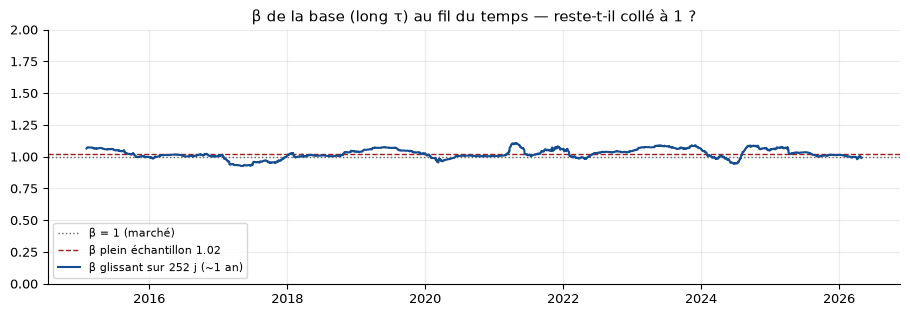

In [44]:
# β GLISSANT de la base (long τ) : β_t = cov(excès strat, excès marché)/var(excès marché) sur 1 an glissant
W_BETA = 252                                             # ~1 an de bourse
rr = spanA.pct_change().dropna()
dd = pd.DataFrame({"p": rr, "m": r_spy.reindex(rr.index)}).join(ff[["RF"]]).dropna()
yb, xb = dd.p - dd.RF, dd.m - dd.RF                      # excès stratégie / excès marché
beta_t = (yb.rolling(W_BETA).cov(xb) / xb.rolling(W_BETA).var()).dropna()
b_full = np.polyfit(xb.values, yb.values, 1)[0]
print(f"β glissant {W_BETA} j — min {beta_t.min():.2f} · médiane {beta_t.median():.2f} · max {beta_t.max():.2f} · plein échantillon {b_full:.2f}")
fig, ax = plt.subplots(figsize=(11, 3.3))
ax.axhline(1.0, color=GRIS, lw=1.0, ls=":", label="β = 1 (marché)")
ax.axhline(b_full, color=ROUGE, lw=1.0, ls="--", label=f"β plein échantillon {b_full:.2f}")
ax.plot(beta_t.index, beta_t, color=BLEU, lw=1.5, label=f"β glissant sur {W_BETA} j (~1 an)")
ax.set_ylim(0, 2); ax.set_title("β de la base (long τ) au fil du temps — reste-t-il collé à 1 ?")
ax.legend(loc="lower left", fontsize=8)
plt.savefig(f"{FIGS}/beta_glissant.png", dpi=150, bbox_inches="tight"); plt.show()

## §11 — Le vrai test : à la date de **divulgation**

Jusqu'ici le flux est fenêtré sur $\tau$ (la transaction) : on utilise une information **avant qu'elle soit
publique** → borne haute. On bascule le fenêtrage sur $\delta$ (la divulgation) : à la coupe $t$, on ne voit
que les trades **déjà divulgués** ($\delta_k \le t$). C'est la version **réplicable**.

Ce qui change : **uniquement la fenêtre du signal**. Le FIFO et $\gamma$ restent sur $\tau$ — la durée de
détention est une réalité, pas une question de date de publication. Exécution toujours au close J+1.

In [45]:
# bascule le fenêtrage sur δ (divulgation), on rebâtit la chaîne longue (sans cap, comparable au run A)
ordre_d = np.argsort(df.ide.values, kind="stable")
IW, ordreW = df.ide.values[ordre_d], ordre_d
SELd = {i: selection(i, W) for i in coupes}
ACHd = {i: acheteurs(i, SELd[i], W) for i in coupes}
WPOd = {i: poids(i, W, SELd[i], ACHd[i]) for i in coupes[:-1]}
td = np.array([len(SELd[i]) for i in coupes])
print(f"à δ — |S_t| médian {np.median(td):.0f} (vs 64 à τ) · mois vides {(td==0).sum()}/{len(td)}")
print(f"lag de divulgation δ−τ : médiane {(df.disclosure_date - df.tau).dt.days.median():.0f} j (le décalage qu'on subit en attendant que l'info soit publique)")
spanD, _ = run_livre(WPOd, np.inf)
IW, ordreW = I0, ordre                                        # on remet τ pour ne rien polluer
print(f"NAV finale — τ (borne haute) {spanA.iloc[-1]:.0f}  ·  δ (réplicable) {spanD.iloc[-1]:.0f}")

à δ — |S_t| médian 59 (vs 64 à τ) · mois vides 0/150
lag de divulgation δ−τ : médiane 27 j (le décalage qu'on subit en attendant que l'info soit publique)
NAV finale — τ (borne haute) 622  ·  δ (réplicable) 530


In [46]:
tabD = pd.DataFrame([bilan(spanA, "τ · transaction (borne haute)"),
                     bilan(spanD, "δ · divulgation (réplicable)")]).set_index("run")
tabD.round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
τ · transaction (borne haute),1.706,1.030,1.048,0.645,1.023,622.132,7/13
δ · divulgation (réplicable),0.350,0.183,-0.032,-0.019,1.010,530.210,7/13


In [47]:
# excès annuel τ vs δ (alimente le tableau annuel de la fiche)
def annuel(Vx):
    rx = Vx.pct_change().dropna()
    s = rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    m = r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))
    return (100*s).round(1), (100*m).round(1), (100*(s-m)).round(1)
sA,mA,xA = annuel(spanA); sD,mD,xD = annuel(spanD)
annu = pd.DataFrame({"strat_τ":sA,"SPY":mA,"excès_τ":xA,"strat_δ":sD,"excès_δ":xD})
print("excès τ:", list(xA.values)); print("excès δ:", list(xD.values))
annu

excès τ: [np.float64(-1.3), np.float64(-0.9), np.float64(9.4), np.float64(3.0), np.float64(0.9), np.float64(-3.4), np.float64(3.5), np.float64(2.0), np.float64(-3.1), np.float64(11.5), np.float64(-8.7), np.float64(10.9), np.float64(-1.6)]
excès δ: [np.float64(2.2), np.float64(0.1), np.float64(11.1), np.float64(3.7), np.float64(-2.4), np.float64(3.0), np.float64(-9.6), np.float64(13.2), np.float64(-1.6), np.float64(-3.8), np.float64(-9.4), np.float64(3.5), np.float64(-5.4)]


,strat_τ,SPY,excès_τ,strat_δ,excès_δ
Date,,,,,
2014,19.0,20.3,-1.3,22.6,2.2
2015,0.4,1.2,-0.9,1.3,0.1
2016,21.4,12.0,9.4,23.1,11.1
2017,24.7,21.7,3.0,25.4,3.7
2018,-3.7,-4.6,0.9,-7.0,-2.4
2019,27.9,31.2,-3.4,34.2,3.0
2020,21.8,18.3,3.5,8.7,-9.6
2021,30.7,28.7,2.0,41.9,13.2
2022,-21.2,-18.2,-3.1,-19.8,-1.6


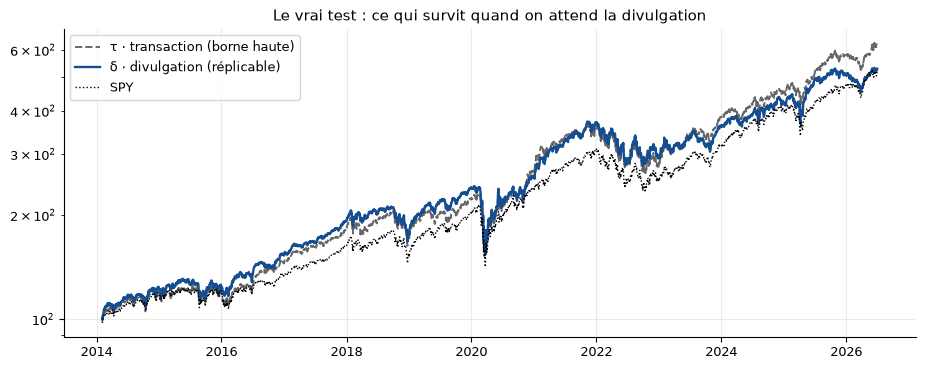

In [48]:
navspy3 = (1 + r_spy.reindex(spanA.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spanA.index, spanA, color=GRIS, lw=1.4, ls="--", label="τ · transaction (borne haute)")
ax.plot(spanD.index, spanD, color=BLEU, lw=1.7, label="δ · divulgation (réplicable)")
ax.plot(navspy3.index, navspy3, color="k", lw=1.0, ls=":", label="SPY")
ax.set_yscale("log"); ax.set_title("Le vrai test : ce qui survit quand on attend la divulgation"); ax.legend()
plt.savefig(f"{FIGS}/divulgation.png", dpi=150, bbox_inches="tight"); plt.show()

### §11bis — Divulgation ET cap de rotation (les 4 coins)

On croise les deux réglages : borne du signal (τ / δ) $\times$ cap de rotation (sans / 25 %/mois). Le run
manquant est **δ + cap** = `run_livre(WPOd, TAU_MAX)`. On voit ainsi l'effet du cap séparément à τ et à δ.

In [49]:
spanD_cap, _ = run_livre(WPOd, TAU_MAX)                       # base à δ, avec cap 25 %/mois
tab4 = pd.DataFrame([bilan(spanA,     "τ · sans cap"),
                     bilan(spanB,     "τ · cap 25 %"),
                     bilan(spanD,     "δ · sans cap"),
                     bilan(spanD_cap, "δ · cap 25 %")]).set_index("run")
tab4.round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
τ · sans cap,1.706,1.030,1.048,0.645,1.023,622.132,7/13
τ · cap 25 %,0.269,0.233,-0.158,-0.116,1.014,530.993,6/13
δ · sans cap,0.350,0.183,-0.032,-0.019,1.010,530.210,7/13
δ · cap 25 %,-0.490,-0.382,-0.672,-0.540,1.004,487.341,7/13


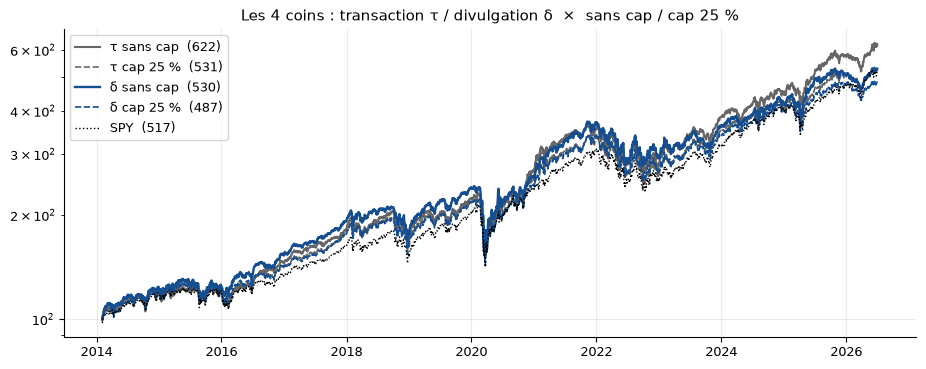

In [50]:
navspy4 = (1 + r_spy.reindex(spanA.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spanA.index,     spanA,     color=GRIS, lw=1.5,          label=f"τ sans cap  ({spanA.iloc[-1]:.0f})")
ax.plot(spanB.index,     spanB,     color=GRIS, lw=1.2, ls="--", label=f"τ cap 25 %  ({spanB.iloc[-1]:.0f})")
ax.plot(spanD.index,     spanD,     color=BLEU, lw=1.7,          label=f"δ sans cap  ({spanD.iloc[-1]:.0f})")
ax.plot(spanD_cap.index, spanD_cap, color=BLEU, lw=1.2, ls="--", label=f"δ cap 25 %  ({spanD_cap.iloc[-1]:.0f})")
ax.plot(navspy4.index, navspy4, color="k", lw=1.0, ls=":",       label=f"SPY  ({navspy4.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend()
ax.set_title("Les 4 coins : transaction τ / divulgation δ  ×  sans cap / cap 25 %")
plt.savefig(f"{FIGS}/coins.png", dpi=150, bbox_inches="tight"); plt.show()

## §12 — D'autres pistes

Jusqu'ici, à la divulgation, le ticker suit le marché (β≈1) et l'excès tombe à ~0. On explore trois causes
possibles de ce nul, plus deux découpages rapides. **Chaque piste est mesurée à τ (borne haute) ET à δ
(réplicable)** ; ces sections ajoutent des essais au compteur de multiplicité (§12.6). Aucune n'est un verdict.

**Les leviers.** ① *horizon* (tenir plus longtemps — Pyun trouve le signal vers 300 j) · ② *comités*
(ne garder que les membres siégeant sur le comité du secteur — le prédicteur le plus documenté) · ③ *marché
neutralisé* (retirer β·marché pour voir la sélection pure) · ④ *Sénat seul* · ⑤ *dépôts tardifs*.

In [51]:
# helper — rejoue TOUTE la chaîne du signal sur un sous-ensemble de trades (mask), à τ puis à δ.
# On swappe les globals que lisent flux/selection/acheteurs (df, IW, ordreW) ; γ voyage avec les lignes
# (la purge FIFO reste calculée sur l'historique complet, §4). run_livre/poids ne touchent pas à df.
def variante(mask, W=W, tau_max=np.inf, cotes=("tau","delta")):
    # rejoue le signal sur le sous-ensemble mask ; tau_max<∞ = cap de rotation ; cotes = quelles bornes
    global df, IW, ordreW
    bak = (df, IW, ordreW)
    try:
        dv = df[mask].reset_index(drop=True)
        idxmap = {"tau": dv.i0.values, "delta": dv.ide.values}
        df = dv
        spans = {}
        for lab in cotes:
            order = np.argsort(idxmap[lab], kind="stable")
            IW, ordreW = idxmap[lab][order], order
            SELv = {i: selection(i, W) for i in coupes}
            WPv  = {i: poids(i, W, SELv[i], acheteurs(i, SELv[i], W)) for i in coupes[:-1]}
            spans[lab] = run_livre(WPv, tau_max)[0]
        return (spans.get("tau"), spans.get("delta"), int(mask.sum()))
    finally:
        df, IW, ordreW = bak

def taille_sel(mask, cote, W=W):
    # tailles |S| du signal restreint, sans lancer le backtest (pour diagnostiquer τ vs δ)
    global df, IW, ordreW
    bak = (df, IW, ordreW)
    try:
        dv = df[mask].reset_index(drop=True)
        idx = dv.i0.values if cote == "tau" else dv.ide.values
        order = np.argsort(idx, kind="stable")
        df, IW, ordreW = dv, idx[order], order
        return np.array([len(selection(i, W)) for i in coupes])
    finally:
        df, IW, ordreW = bak

# contrôle : variante(tout) doit reproduire la base (spanA / spanD)
st, sd, n = variante(pd.Series(True, index=df.index))
print(f"contrôle variante(tout) : NAV τ {st.iloc[-1]:.1f} (base {spanA.iloc[-1]:.1f}) · "
      f"NAV δ {sd.iloc[-1]:.1f} (base {spanD.iloc[-1]:.1f})  → {n:,} trades")
assert abs(st.iloc[-1]-spanA.iloc[-1])<1e-6 and abs(sd.iloc[-1]-spanD.iloc[-1])<1e-6, "le swap ne reproduit pas la base"

contrôle variante(tout) : NAV τ 622.1 (base 622.1) · NAV δ 530.2 (base 530.2)  → 113,369 trades


### §12.1 — Horizon : tenir plus longtemps

On détient, au mois $t$, la **moyenne des portefeuilles cibles des $H$ derniers mois** (cohortes
chevauchantes, chacune $1/H$) : $w^{(H)}_t = \frac{1}{H}\sum_{h=0}^{H-1} w_{t-h}$, renormalisé. $H{=}1$
redonne la base. On balaie $H \in \{1,3,6,12\}$ mois, à τ et à δ.

In [52]:
def overlap(WP, H):
    ks = sorted(WP.keys()); out = {}
    for j, k in enumerate(ks):
        agg = {}
        for jj in range(max(0, j-H+1), j+1):
            for tk, wi in WP[ks[jj]].items(): agg[tk] = agg.get(tk, 0.0) + wi
        s = sum(agg.values())
        out[k] = {tk: wi/s for tk, wi in agg.items()} if s > 0 else {}
    return out

rows_h = []
for H in [1, 3, 6, 12]:
    for lab, WP in [("τ", WPO), ("δ", WPOd)]:
        span = run_livre(overlap(WP, H), np.inf)[0]
        rows_h.append(bilan(span, f"H={H:>2} mois · {lab}"))
tab_h = pd.DataFrame(rows_h).set_index("run")
print("horizon de détention — H=1 = la base"); tab_h.round(3)

horizon de détention — H=1 = la base


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
H= 1 mois · τ,1.706,1.030,1.048,0.645,1.023,622.132,7/13
H= 1 mois · δ,0.350,0.183,-0.032,-0.019,1.010,530.210,7/13
H= 3 mois · τ,0.273,0.184,-0.430,-0.298,1.025,522.315,6/13
H= 3 mois · δ,-0.508,-0.322,-0.830,-0.607,1.012,478.144,7/13
H= 6 mois · τ,-0.533,-0.470,-0.848,-0.682,1.018,483.370,7/13
H= 6 mois · δ,-0.287,-0.244,-0.509,-0.411,1.007,499.077,7/13
H=12 mois · τ,-1.082,-1.068,-1.493,-1.256,1.021,456.417,5/13
H=12 mois · δ,-0.892,-0.787,-1.085,-0.871,1.012,468.659,6/13


### §12.2 — Comités pertinents

**L'idée.** Un élu qui siège au comité régulant un secteur a un avantage d'information sur ce secteur. On ne
garde donc, dans le signal, que les achats d'un membre siégeant sur un comité **ayant juridiction sur le
secteur GICS du titre acheté**.

**Le filtre.** À chaque membre $m$ on associe l'ensemble des secteurs couverts par ses comités :
$$\mathrm{Sec}(m) = \bigcup_{c\,\in\,\text{comités}(m)} \text{secteurs}(c)$$
Un trade $k = (m_k, i_k, \dots)$ est **retenu** si et seulement si le titre est dans la juridiction du membre :
$$k \text{ retenu} \iff \text{secteur}(i_k) \in \mathrm{Sec}(m_k)$$

**Tout le reste est IDENTIQUE à la base --- et c'est du LONG.** On rejoue la même chaîne (§5-§8) mais sur ce
sous-ensemble de trades. Flux et signal restreints (exposant $c$ = « comité ») :
$$NetBuy^{c}_{i,t} = \!\!\!\sum_{k\text{ retenu, achat}}\!\!\! A_k \;-\; \!\!\!\sum_{k\text{ retenu, vente}}\!\!\! A_k\gamma_k,
\qquad S^{c}_t = \{\, i : NetBuy^{c}_{i,t} > 0 \;\wedge\; nBuyers^{c}_{i,t} \ge 2 \,\}$$
Poids **une voix par membre**, restreint aux $K^c_t$ membres pertinents ($\mathcal{M}^c_t$ = membres retenus
ayant acheté un titre de $S^c_t$, $B^c_{m,t}$ = leurs titres) :
$$\boxed{\; w^{c}_{i,t} = \frac{1}{K^{c}_t} \sum_{m \in \mathcal{M}^{c}_t} \frac{\mathbf{1}\{i \in B^{c}_{m,t}\}}{|B^{c}_{m,t}|} \;}
\qquad \sum_i w^{c}_{i,t} = 1$$
On **achète** les titres de $S^c_t$ avec ces poids (aucune vente à découvert), on tient un mois, exécution au
close J+1 --- le moteur §7-§8 tel quel. **Seule la population de trades change.** Variante de robustesse plus
grossière : `committees_key_flag` (le membre est sur un comité « clé », sans regarder le secteur).

In [53]:
# carte comité -> secteurs GICS (juridictions les plus défendables)
COM_SEC = {
 "Financial Services":            {"Financials"},
 "Armed Services":                {"Industrials"},
 "Energy and Commerce":           {"Energy","Health Care","Communication Services","Utilities"},
 "Natural Resources":             {"Energy","Materials","Utilities"},
 "Agriculture":                   {"Consumer Staples","Materials"},
 "Transportation and Infrastructure": {"Industrials"},
 "Science, Space, and Technology":{"Information Technology"},
 "Homeland Security":             {"Industrials","Information Technology"},
 "Veterans":                      {"Health Care"},
}
def com_secteurs(s):
    if not isinstance(s, str): return set()
    out = set()
    for nom, secs in COM_SEC.items():
        if nom in s: out |= secs
    return out
comsec = df.committee_membership.map(com_secteurs)
mask_com = pd.Series([sg in cs for sg, cs in zip(df.sector_gics, comsec)], index=df.index)
mask_key = (df.committees_key_flag == True)
print(f"trades comité-pertinents (secteur) : {mask_com.sum():,} / {len(df):,} ({mask_com.mean():.1%})")
print(f"trades sur comité « clé » (flag)    : {mask_key.sum():,} / {len(df):,} ({mask_key.mean():.1%})")
carte = pd.DataFrame([{"comité (House)": k, "secteurs GICS régulés": ", ".join(sorted(v))} for k, v in COM_SEC.items()])
print("\nla carte comité → secteur :"); display(carte)
print("exemples de trades RETENUS (le titre est dans la juridiction du membre) :")
display(df[mask_com][["member_name","tk","sector_gics","op"]].head(6))

trades comité-pertinents (secteur) : 18,948 / 113,369 (16.7%)
trades sur comité « clé » (flag)    : 63,912 / 113,369 (56.4%)

la carte comité → secteur :


,comité (House),secteurs GICS régulés
0,Financial Services,Financials
1,Armed Services,Industrials
2,Energy and Commerce,"Communication Services, Energy, Health Care, U..."
3,Natural Resources,"Energy, Materials, Utilities"
4,Agriculture,"Consumer Staples, Materials"
5,Transportation and Infrastructure,Industrials
6,"Science, Space, and Technology",Information Technology
7,Homeland Security,"Industrials, Information Technology"
8,Veterans,Health Care


exemples de trades RETENUS (le titre est dans la juridiction du membre) :


,member_name,tk,sector_gics,op
11,Michael T. McCaul,TSM,Information Technology,buy
22,Michael T. McCaul,TSM,Information Technology,buy
41,Michael T. McCaul,XRX,Industrials,sell
55,Nick J. Rahall,MTZ,Industrials,sell
57,Lamar Smith,GWRE,Information Technology,buy
71,Nick J. Rahall,GE,Industrials,sell


**Un exemple d'allocation, à une coupe.** Pour lever le doute : on est bien en **long**, chaque membre
pertinent pèse $1/K^c$ et le répartit également entre ses titres. Voici une coupe réelle.

In [54]:
# EXEMPLE concret à une coupe : le portefeuille LONG comité-secteur, membre par membre
dv = df[mask_com].reset_index(drop=True); ov = np.argsort(dv.i0.values, kind="stable")
_bdf, _bIW, _bow = df, IW, ordreW
df, IW, ordreW = dv, dv.i0.values[ov], ov
ic = coupes[len(coupes)*2//3]                                  # une coupe aux deux tiers de la période
Sc = selection(ic, W); Ac = acheteurs(ic, Sc, W); wc = poids(ic, W, Sc, Ac)
df, IW, ordreW = _bdf, _bIW, _bow                             # on remet la population complète
Kc = len(Ac)
print(f"coupe du {cal[ic].date()} — {Kc} membres pertinents · {len(Sc)} titres retenus · LONG seul · Σ w = {sum(wc.values()):.4f}")
ex = pd.DataFrame([{"membre": df.loc[df.bioguide_id==m,'member_name'].iat[0],
                    "|B_m| (nb titres)": len(v), "poids/titre = 1/(K·|B_m|)": 1/(Kc*len(v)),
                    "ses titres retenus": ", ".join(v[:5])} for m, v in list(Ac.items())[:8]])
display(ex.round(4))

coupe du 2022-05-31 — 4 membres pertinents · 4 titres retenus · LONG seul · Σ w = 1.0000


,membre,|B_m| (nb titres),poids/titre = 1/(K·|B_m|),ses titres retenus
0,Diana Harshbarger,1,0.2500,GNRC
1,Rohit Khanna,4,0.0625,"DOV, FDX, GNRC, UPS"
2,James R. Langevin,1,0.2500,GNRC
3,Michael T. McCaul,3,0.0833,"DOV, FDX, UPS"


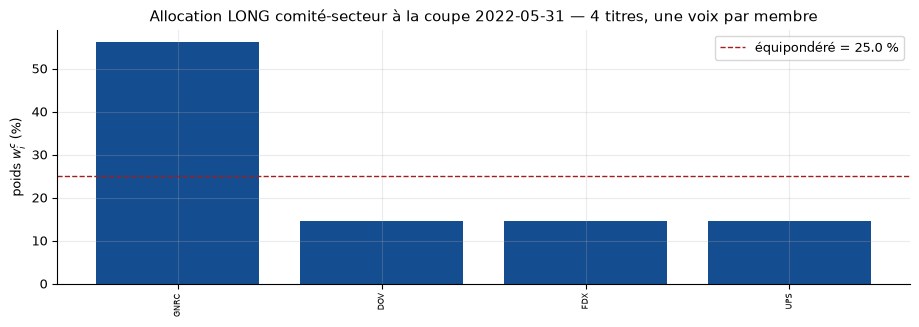

In [55]:
# les poids finaux w^c_i à cette coupe — la 'photo' de l'allocation
ws = pd.Series(wc).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 3.3))
ax.bar(range(len(ws)), ws.values*100, color=BLEU)
ax.axhline(100/len(ws), color=ROUGE, ls="--", lw=1, label=f"équipondéré = {100/len(ws):.1f} %")
ax.set_xticks(range(len(ws))); ax.set_xticklabels(ws.index, rotation=90, fontsize=6)
ax.set_ylabel("poids $w^c_i$ (%)"); ax.set_title(f"Allocation LONG comité-secteur à la coupe {cal[ic].date()} — {len(ws)} titres, une voix par membre")
ax.legend(); plt.savefig(f"{FIGS}/comites_alloc.png", dpi=150, bbox_inches="tight"); plt.show()

In [56]:
# les runs (on GARDE les NAV pour la figure) : comité-secteur et comité-clé, à τ et δ
stc, sdc, nc = variante(mask_com)
stk, sdk, nk = variante(mask_key)
tab_c = pd.DataFrame([bilan(stc, "comité-secteur · τ"), bilan(sdc, "comité-secteur · δ"),
                      bilan(stk, "comité-clé (flag) · τ"), bilan(sdk, "comité-clé (flag) · δ")]).set_index("run")
print(f"comité-secteur : {nc:,} trades · comité-clé : {nk:,} trades · base τ NAV 622 / δ NAV 530 pour comparaison")
display(tab_c.round(3))

comité-secteur : 18,948 trades · comité-clé : 63,912 trades · base τ NAV 622 / δ NAV 530 pour comparaison


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
comité-secteur · τ,7.667,1.599,5.947,1.352,1.001,1102.350,9/13
comité-secteur · δ,-3.645,-0.992,-3.137,-0.752,0.991,325.779,5/13
comité-clé (flag) · τ,1.739,0.697,0.612,0.283,1.040,608.888,7/13
comité-clé (flag) · δ,-1.053,-0.557,-1.428,-0.649,1.033,454.133,6/13


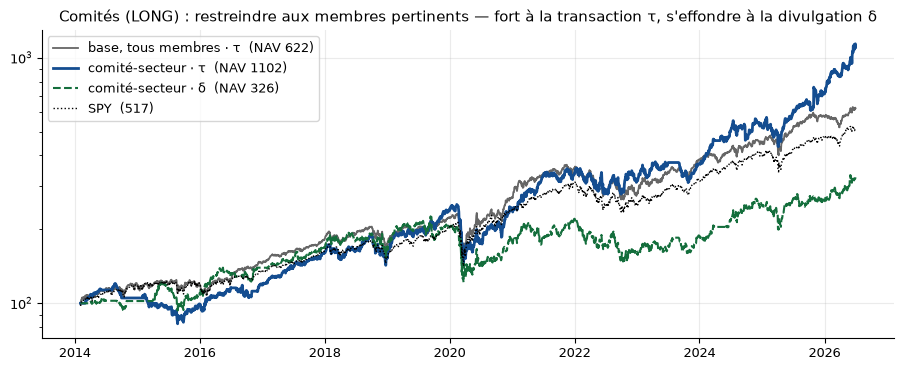

In [57]:
# LA figure : restreindre aux comités (LONG) double la NAV à τ, mais s'effondre à δ
navspy = (1 + r_spy.reindex(spanA.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(spanA.index, spanA, color=GRIS, lw=1.3,           label=f"base, tous membres · τ  (NAV {spanA.iloc[-1]:.0f})")
ax.plot(stc.index,   stc,   color=BLEU, lw=2.0,           label=f"comité-secteur · τ  (NAV {stc.iloc[-1]:.0f})")
ax.plot(sdc.index,   sdc,   color=VERT, lw=1.5, ls="--",  label=f"comité-secteur · δ  (NAV {sdc.iloc[-1]:.0f})")
ax.plot(navspy.index, navspy, color="k", lw=1.0, ls=":",  label=f"SPY  ({navspy.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend()
ax.set_title("Comités (LONG) : restreindre aux membres pertinents — fort à la transaction τ, s'effondre à la divulgation δ")
plt.savefig(f"{FIGS}/comites.png", dpi=150, bbox_inches="tight"); plt.show()

### §12.2bis — Diagnostic : ce +7,7 % à τ est-il réel ?

Trois doutes à lever par la mesure : **(a)** la carte comité→secteur est-elle un vrai filtre d'information,
ou un simple **pari sectoriel** ? **(b)** pourquoi l'effondrement à δ ? **(c)** que donne le **cap** ?

part des trades de chaque secteur que le filtre comité-secteur RETIENT :


,retenus,part,total
sector_gics,,,
Industrials,8857,0.634,13971
Information Technology,3985,0.202,19708
Materials,840,0.182,4628
Consumer Staples,1082,0.132,8181
Energy,736,0.114,6470
Health Care,1699,0.112,15131
Utilities,251,0.110,2286
Financials,1165,0.070,16681
Communication Services,333,0.038,8748


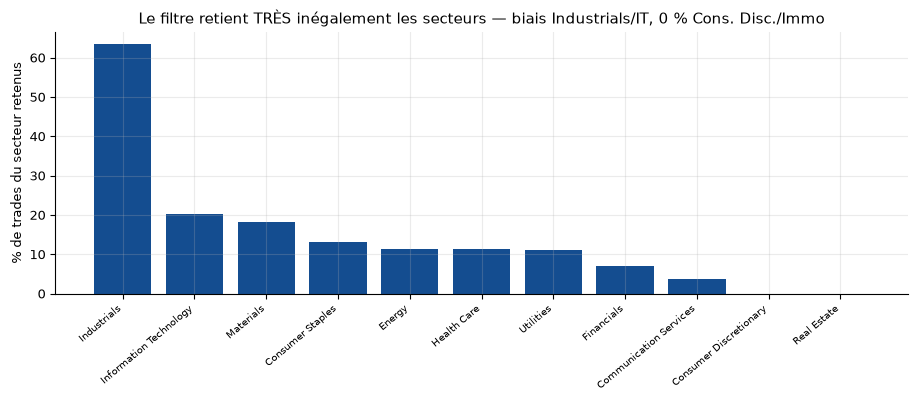

In [58]:
# (a) composition sectorielle des trades retenus — le filtre est-il équilibré ?
comp = (df.assign(ret=mask_com).groupby("sector_gics").ret
          .agg(retenus="sum", part="mean", total="size").sort_values("part", ascending=False))
print("part des trades de chaque secteur que le filtre comité-secteur RETIENT :")
display(comp.round(3))
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(comp.index, comp["part"]*100, color=BLEU)
ax.set_ylabel("% de trades du secteur retenus"); ax.set_xticklabels(comp.index, rotation=40, ha="right", fontsize=7)
ax.set_title("Le filtre retient TRÈS inégalement les secteurs — biais Industrials/IT, 0 % Cons. Disc./Immo")
plt.savefig(f"{FIGS}/comites_secteurs.png", dpi=150, bbox_inches="tight"); plt.show()

**Placebo.** On casse le lien réel *membre↔comité* : chaque membre reçoit le comité d'un autre membre
(permutation aléatoire, graine fixe), et on rejoue à τ. Si l'excès reste voisin du $+7,7\,\%$ réel, c'est
que le résultat vient du **tilt sectoriel** (le filtre surpondère Industrials/IT quel que soit qui siège où),
pas de l'information de comité. On répète 20 fois.

excès τ RÉEL (vraie affectation comité) : +7.67 %/an
placebo (comité au hasard, 20 tirages) : médiane +0.41 · min -8.31 · max +8.31 %/an
le réel dépasse 90% des placebos


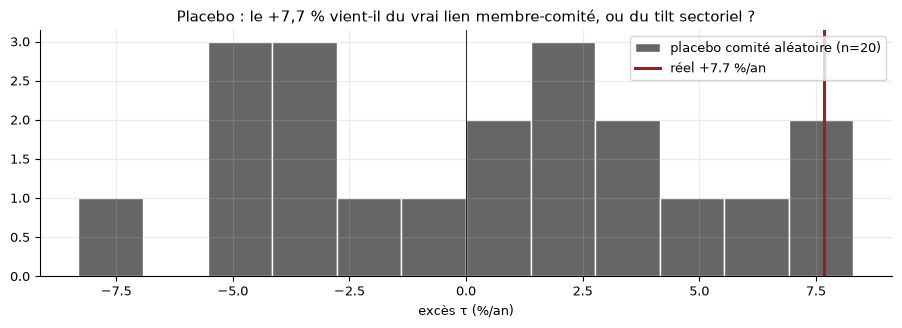

In [59]:
def run_tau_only(mask):
    st, _, _ = variante(mask, cotes=("tau",)); return st
np.random.seed(7)
memb = df.groupby("bioguide_id").committee_membership.first()
reel = bilan(stc, "reel")["excès %/an"]
placebo = []
for rep in range(20):
    perm = pd.Series(np.random.permutation(memb.values), index=memb.index)
    fake = df.bioguide_id.map(perm).map(com_secteurs)
    m = pd.Series([sg in cs for sg, cs in zip(df.sector_gics, fake)], index=df.index)
    if m.sum() == 0: continue
    placebo.append(bilan(run_tau_only(m), "p")["excès %/an"])
placebo = np.array(placebo)
print(f"excès τ RÉEL (vraie affectation comité) : {reel:+.2f} %/an")
print(f"placebo (comité au hasard, {len(placebo)} tirages) : médiane {np.median(placebo):+.2f} · "
      f"min {placebo.min():+.2f} · max {placebo.max():+.2f} %/an")
print(f"le réel dépasse {(placebo < reel).mean():.0%} des placebos")
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.hist(placebo, bins=12, color=GRIS, edgecolor="white", label=f"placebo comité aléatoire (n={len(placebo)})")
ax.axvline(reel, color=ROUGE, lw=2.2, label=f"réel {reel:+.1f} %/an")
ax.axvline(0, color="k", lw=0.6); ax.set_xlabel("excès τ (%/an)")
ax.set_title("Placebo : le +7,7 % vient-il du vrai lien membre-comité, ou du tilt sectoriel ?")
ax.legend(); plt.savefig(f"{FIGS}/comites_placebo.png", dpi=150, bbox_inches="tight"); plt.show()

**(b) L'effondrement τ→δ.** Taille du signal restreint, mois vides, et excès **année par année** — pour
voir si le $-3,65\,\%$ à δ est large ou porté par 1-2 années / un petit échantillon.

|S^c| médian — τ 4 · δ 4
mois vides   — τ 12/150 · δ 15/150   |   mois < 3 titres — τ 47 · δ 48

excès annuel comité-secteur — moyennes τ +7.68 · δ -3.66


,excès_τ (%),excès_δ (%)
Date,,
2014,-15.2,-18.2
2015,-7.2,5.1
2016,7.9,16.5
2017,13.4,-1.1
2018,0.6,3.3
2019,23.9,-9.0
2020,-16.6,-30.0
2021,10.4,-5.7
2022,12.0,-9.5


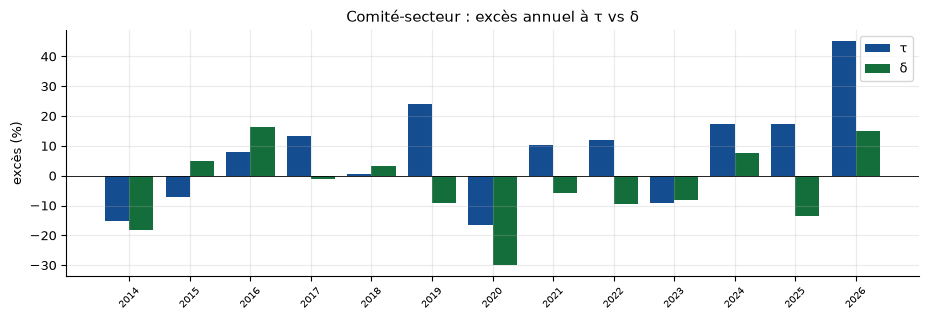

In [60]:
tSt, tSd = taille_sel(mask_com, "tau"), taille_sel(mask_com, "delta")
print(f"|S^c| médian — τ {np.median(tSt):.0f} · δ {np.median(tSd):.0f}")
print(f"mois vides   — τ {(tSt==0).sum()}/{len(tSt)} · δ {(tSd==0).sum()}/{len(tSd)}   |   "
      f"mois < 3 titres — τ {(tSt<3).sum()} · δ {(tSd<3).sum()}")
xt = annuel(stc)[2]; xd = annuel(sdc)[2]
annu_c = pd.DataFrame({"excès_τ (%)": xt, "excès_δ (%)": xd})
print(f"\nexcès annuel comité-secteur — moyennes τ {xt.mean():+.2f} · δ {xd.mean():+.2f}")
display(annu_c)
fig, ax = plt.subplots(figsize=(11, 3.2))
yy = annu_c.index.astype(str); x = np.arange(len(yy))
ax.bar(x-0.2, annu_c["excès_τ (%)"], 0.4, color=BLEU, label="τ")
ax.bar(x+0.2, annu_c["excès_δ (%)"], 0.4, color=VERT, label="δ")
ax.axhline(0, color="k", lw=0.6); ax.set_xticks(x); ax.set_xticklabels(yy, rotation=45, fontsize=7)
ax.set_ylabel("excès (%)"); ax.set_title("Comité-secteur : excès annuel à τ vs δ"); ax.legend()
plt.savefig(f"{FIGS}/comites_annuel.png", dpi=150, bbox_inches="tight"); plt.show()

**(c) Le cap sur les comités.** comité-secteur avec cap de rotation 25 %/mois, à τ et δ.

In [61]:
stc_cap, sdc_cap, _ = variante(mask_com, tau_max=TAU_MAX)
pd.DataFrame([bilan(stc,     "comité-secteur · τ  (sans cap)"),
             bilan(stc_cap, "comité-secteur · τ  (cap 25 %)"),
             bilan(sdc,     "comité-secteur · δ  (sans cap)"),
             bilan(sdc_cap, "comité-secteur · δ  (cap 25 %)")]).set_index("run").round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
comité-secteur · τ (sans cap),7.667,1.599,5.947,1.352,1.001,1102.350,9/13
comité-secteur · τ (cap 25 %),2.777,0.881,2.097,0.703,1.017,670.816,8/13
comité-secteur · δ (sans cap),-3.645,-0.992,-3.137,-0.752,0.991,325.779,5/13
comité-secteur · δ (cap 25 %),-2.385,-0.987,-1.899,-0.646,1.020,388.781,6/13


### §12.3 — Marché neutralisé : isoler la sélection

Le β≈1 masque toute sélection. On retire, jour après jour, $\hat\beta_t \cdot (r_{\text{SPY}}-r_f)$
($\hat\beta_t$ = β glissant 252 j) : le résidu $(r-r_f) - \hat\beta_t (r_{\text{SPY}}-r_f)$ est le
**P\&L de sélection pur**. On le mesure sur la base, à τ et à δ. $\alpha$/an, $t_\alpha$, volatilité.

In [62]:
def neutre(span, nom):
    r = span.pct_change().dropna()
    dd = pd.DataFrame({"p": r, "m": r_spy.reindex(r.index)}).join(ff[["RF"]]).dropna()
    yy, xx = dd.p - dd.RF, dd.m - dd.RF
    b_full = np.polyfit(xx.values, yy.values, 1)[0]
    beta = (yy.rolling(252).cov(xx) / xx.rolling(252).var()).fillna(b_full)
    resid = (yy - beta*xx).dropna()
    t = resid.mean()/(resid.std(ddof=1)/np.sqrt(len(resid)))
    nav = 100*(1+resid).cumprod().iloc[-1]
    return {"run": nom, "α %/an": 252*resid.mean()*100, "t_α": t,
            "vol %/an": resid.std()*np.sqrt(252)*100, "NAV sélection": nav}
tab_n = pd.DataFrame([neutre(spanA, "base neutralisée · τ"),
                      neutre(spanD, "base neutralisée · δ")]).set_index("run")
print("après retrait de β·marché : ce qui reste = sélection pure"); tab_n.round(3)

après retrait de β·marché : ce qui reste = sélection pure


,α %/an,t_α,vol %/an,NAV sélection
run,,,,
base neutralisée · τ,1.080,0.665,5.678,111.884
base neutralisée · δ,0.031,0.019,5.797,98.346


### §12.4 / §12.5 — Sénat seul · dépôts tardifs

**Sénat** (Lazzaretto : signal plus fort à la chambre haute, mais petit échantillon → puissance limitée).
**Tardifs** : trades déposés en retard (`flag_late_filing`) — hypothèse d'un trade qu'on préfère cacher.

In [63]:
rows_f = []
for nom, m in [("Sénat seul", df.chamber == "senate"), ("dépôts tardifs", df.flag_late_filing == True)]:
    st, sd, n = variante(m)
    print(f"{nom} : {n:,} trades")
    rows_f += [bilan(st, f"{nom} · τ"), bilan(sd, f"{nom} · δ")]
tab_f = pd.DataFrame(rows_f).set_index("run")
tab_f.round(3)

Sénat seul : 9,246 trades


dépôts tardifs : 13,037 trades


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
Sénat seul · τ,-2.540,-0.402,-0.745,-0.155,0.833,359.002,6/13
Sénat seul · δ,-3.722,-0.572,1.779,0.326,0.620,287.046,6/13
dépôts tardifs · τ,2.061,0.492,4.470,0.865,0.895,632.524,7/13
dépôts tardifs · δ,-8.252,-1.983,-0.106,-0.027,0.389,199.782,4/13


### §12.6 — Récapitulatif et multiplicité

Toutes les pistes côte à côte. **Déclaration honnête** : ces essais s'ajoutent au compteur — plus on teste,
plus un $t$ élevé peut sortir par hasard. On lit chaque $t$ face au nombre total d'essais (E$[\max t]$ croît
avec le nombre de tirages). Le run revendiquable reste **δ** (réplicable) ; τ est une borne haute.

In [64]:
recap = pd.concat([tab_h, tab_c, tab_f]).round(3)
n_essais = len(recap) + 2                      # + les 2 neutralisées
import math
print(f"nombre d'essais §12 : {n_essais}  →  E[max |t|] sous H0 ≈ {math.sqrt(2*math.log(n_essais)):.2f} (bruit)")
# le meilleur candidat à δ (hors base), pour l'œil — PAS un verdict
d = recap[recap.index.str.endswith('δ')].copy()
d["|t|"] = d["t"].abs()
print("\nmeilleurs |t| à δ :")
display(d.sort_values("|t|", ascending=False)[["excès %/an","t","α %/an","β","NAV"]].head(6))
recap

nombre d'essais §12 : 18  →  E[max |t|] sous H0 ≈ 2.40 (bruit)

meilleurs |t| à δ :


,excès %/an,t,α %/an,β,NAV
run,,,,,
dépôts tardifs · δ,-8.252,-1.983,-0.106,0.389,199.782
comité-secteur · δ,-3.645,-0.992,-3.137,0.991,325.779
H=12 mois · δ,-0.892,-0.787,-1.085,1.012,468.659
Sénat seul · δ,-3.722,-0.572,1.779,0.620,287.046
comité-clé (flag) · δ,-1.053,-0.557,-1.428,1.033,454.133
H= 3 mois · δ,-0.508,-0.322,-0.830,1.012,478.144


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
H= 1 mois · τ,1.706,1.030,1.048,0.645,1.023,622.132,7/13
H= 1 mois · δ,0.350,0.183,-0.032,-0.019,1.010,530.210,7/13
H= 3 mois · τ,0.273,0.184,-0.430,-0.298,1.025,522.315,6/13
H= 3 mois · δ,-0.508,-0.322,-0.830,-0.607,1.012,478.144,7/13
H= 6 mois · τ,-0.533,-0.470,-0.848,-0.682,1.018,483.370,7/13
H= 6 mois · δ,-0.287,-0.244,-0.509,-0.411,1.007,499.077,7/13
H=12 mois · τ,-1.082,-1.068,-1.493,-1.256,1.021,456.417,5/13
H=12 mois · δ,-0.892,-0.787,-1.085,-0.871,1.012,468.659,6/13
comité-secteur · τ,7.667,1.599,5.947,1.352,1.001,1102.350,9/13


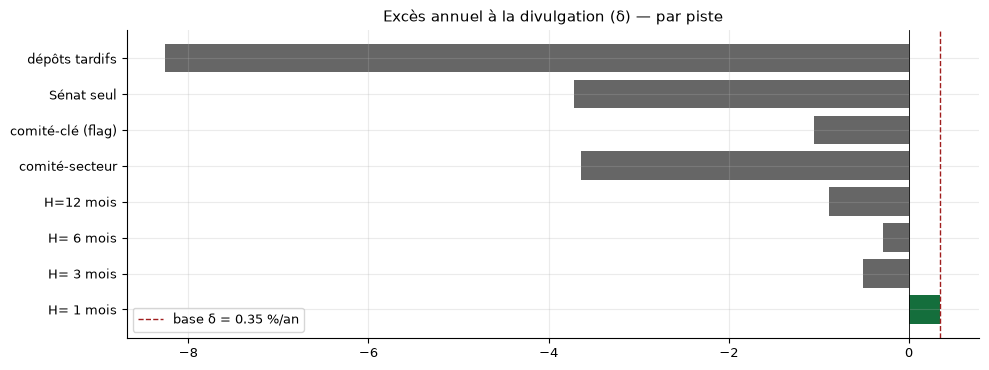

In [65]:
# figure : excès annuel (δ) par piste vs la base — voir si une piste décolle
fig, ax = plt.subplots(figsize=(11, 4))
base_d = bilan(spanD, "base δ")["excès %/an"]
lab = [i.replace(' · δ','') for i in recap.index if i.endswith('δ')]
val = [recap.loc[i,"excès %/an"] for i in recap.index if i.endswith('δ')]
ax.barh(lab, val, color=[VERT if v>base_d else GRIS for v in val])
ax.axvline(base_d, color=ROUGE, ls="--", lw=1, label=f"base δ = {base_d:.2f} %/an")
ax.axvline(0, color="k", lw=0.6)
ax.set_title("Excès annuel à la divulgation (δ) — par piste"); ax.legend()
plt.savefig(f"{FIGS}/pistes.png", dpi=150, bbox_inches="tight"); plt.show()

## §13.0 — Récapitulatif : les trois répliques de produits réels (ce qui est appliqué)

Avant les mesures, voici **exactement ce qu'on applique** pour chaque produit, face à sa **règle publiée**.
Trois colonnes : leur règle (source) · notre code · ce qui est **fidèle / approximé / non-divulgué**.

| réplique | leur règle (source) | ce qu'on applique (code) | fidèle · approximé · non-divulgué | validation |
|---|---|---|---|---|
| **NANC** (Dém.) | achats **nettés** des ventes sur **3 ans**, **pondéré au \$** (midpoint), **100–200** titres, à la **divulgation**, élus d'un parti *(prospectus Subversive)* | `poids_nanc("Democrat")` : net-\$ sur 756 j de δ, garde net\$>0, **top-200**, $w\propto$ net-\$, `run_livre(·,∞)` mensuel | **fidèle** : parti · netting · 3 ans · δ · \$-pond · top-200. **approximé** : rebal. mensuel. **non modélisé** : plafond de position (~8 % réel → NVDA 25 % chez nous), filtre « en poste » | top-10 = NVDA / PANW / AVGO / META = **vrais holdings NANC** ✓ |
| **GOP** (Rép.) | idem, élus **Républicains** | `poids_nanc("Republican")` | idem | β≈1, α≈0 |
| **Quiver Congress Buys** | long des **achats**, **pondéré à la taille (\$)**, rebalancé **hebdo** *(page Quiver ; disclaimer « hypothetical »)* | `poids_taille(mode="dollar", W=63)` : $w\propto\sum\$$ sur 63 j ; `run_livre` **hebdo** *et* mensuel ; à **τ et δ** | **fidèle** : long · \$-pond · hebdo. **non divulgué (choisi)** : fenêtre 63 j, règle de sortie, τ vs δ | β 1,06 ; leurs β/Sharpe ⇒ ~24 % *(§14.1)* |
| **Quiver Long-Short** | **+130 %** achats **−30 %** ventes, pondéré \$ | `longshort` : $1{,}3\,r_{\text{long}}-0{,}3\,r_{\text{short}}$ | **fidèle** : 130/30 ; mêmes approximations | β 1,07 |

Détail et mesures : **§13** (NANC/GOP) · **§14** (Quiver, dont §14.1 « on fait bien ? »).

## §13 — Ce que font les produits réels : réplique fidèle de NANC / GOP

Les ETF **NANC** (élus Démocrates) et **GOP** (Républicains) d'Unusual Whales/Subversive utilisent une
construction **à l'opposé de la nôtre**. Règle exacte du prospectus :
- univers = titres achetés/vendus par les élus d'un parti (+ famille) via les PTR, **en poste** ;
- **fenêtre 3 ans** glissants, **achats nettés contre ventes** du même titre ;
- **pondération au dollar** (milieu de fourchette = `A`) : gros achats, récurrents, multi-élus → surpondérés ;
- **100-200 titres**, rebalancé **à la divulgation** ($\delta$).

$$w^{\text{NANC}}_{i,t} \;\propto\; \Big[\;\textstyle\sum_{k\,:\,\text{parti},\ t-3\text{ans}<\delta_k\le t} A_k\,\big(\mathbf 1_{achat}-\mathbf 1_{vente}\big)\;\Big]^{+}$$

In [66]:
# arrays de fenêtrage sur la DIVULGATION (δ), persistants pour le §13
ordre_d = np.argsort(df.ide.values, kind="stable")
I_de    = df.ide.values[ordre_d]
W3 = 756                                                       # ~3 ans de bourse

def poids_nanc(i1, parti, topN=200):
    # poids ∝ net-$ (achats − ventes, au midpoint) sur 3 ans glissants de DIVULGATION, par parti
    lo, hi = np.searchsorted(I_de, i1 - W3, "right"), np.searchsorted(I_de, i1, "right")
    g = df.iloc[ordre_d[lo:hi]]
    g = g[g.party == parti]
    if not len(g): return {}
    net = (g.A * np.where(g.op == "buy", 1.0, -1.0)).groupby(g.tk).sum()
    net = net[net > 0]
    net = net[[tk for tk in net.index if np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]   # priçable ET encore coté
    net = net.sort_values(ascending=False).head(topN)
    s = net.sum()
    return (net/s).to_dict() if s > 0 else {}

WP_nanc = {i: poids_nanc(i, "Democrat")   for i in coupes[:-1]}
WP_gop  = {i: poids_nanc(i, "Republican") for i in coupes[:-1]}
span_nanc, _ = run_livre(WP_nanc, np.inf)
span_gop,  _ = run_livre(WP_gop,  np.inf)
nN = int(np.median([len(WP_nanc[i]) for i in coupes[:-1] if WP_nanc[i]]))
nG = int(np.median([len(WP_gop[i])  for i in coupes[:-1] if WP_gop[i]]))
print(f"nb de titres détenus (médiane) — NANC {nN} · GOP {nG}  (le prospectus dit 100-200)")
pd.DataFrame([bilan(span_nanc, "réplique NANC (Démocrates)"),
             bilan(span_gop,  "réplique GOP (Républicains)"),
             bilan(spanD,     "notre base à δ (rappel)")]).set_index("run").round(3)

nb de titres détenus (médiane) — NANC 200 · GOP 200  (le prospectus dit 100-200)


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
réplique NANC (Démocrates),0.23,0.178,-0.820,-0.490,1.051,526.737,7/13
réplique GOP (Républicains),0.70,0.230,-0.332,-0.129,1.028,550.203,6/13
notre base à δ (rappel),0.35,0.183,-0.032,-0.019,1.010,530.210,7/13


In [67]:
# VALIDATION de fidélité : les top-poids récents doivent ressembler aux holdings réels de NANC
ic = coupes[-2]
topw = pd.Series(poids_nanc(ic, "Democrat")).sort_values(ascending=False).head(10)
print(f"réplique NANC — top 10 poids à la coupe du {cal[ic].date()} (attendu : NVDA, GOOGL, MSFT, AMZN…) :")
display((topw*100).round(2).rename("poids %").to_frame())

réplique NANC — top 10 poids à la coupe du 2026-05-29 (attendu : NVDA, GOOGL, MSFT, AMZN…) :


,poids %
NVDA,25.55
PANW,9.46
AVGO,9.18
META,4.60
TSM,3.60
GOOG,3.09
NFLX,2.12
PLTR,1.61
VYX,0.99
CRM,0.77


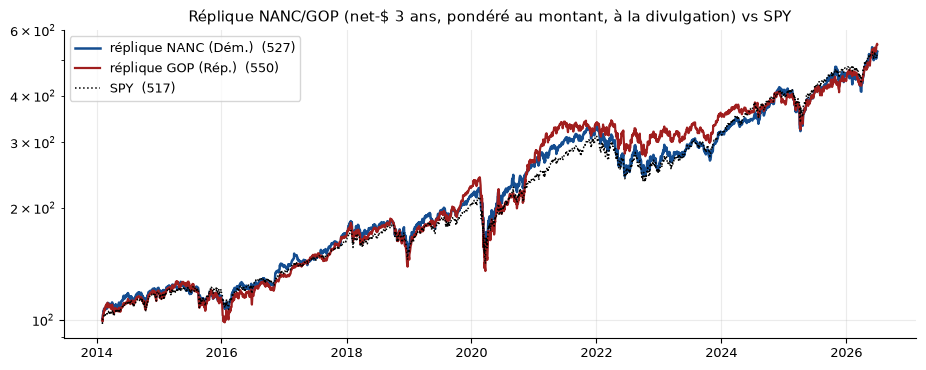

In [68]:
navspyN = (1 + r_spy.reindex(span_nanc.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(span_nanc.index, span_nanc, color=BLEU, lw=1.8, label=f"réplique NANC (Dém.)  ({span_nanc.iloc[-1]:.0f})")
ax.plot(span_gop.index,  span_gop,  color=ROUGE, lw=1.6, label=f"réplique GOP (Rép.)  ({span_gop.iloc[-1]:.0f})")
ax.plot(navspyN.index, navspyN, color="k", lw=1.1, ls=":", label=f"SPY  ({navspyN.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend()
ax.set_title("Réplique NANC/GOP (net-$ 3 ans, pondéré au montant, à la divulgation) vs SPY")
plt.savefig(f"{FIGS}/nanc_gop.png", dpi=150, bbox_inches="tight"); plt.show()

**Rendement TOTAL vs excès.** Le tableau ci-dessus donne l'\emph{excès} (rendement $-$ SPY), pas le total.
On montre ici le **rendement total annualisé** (ce qu'annoncent NANC/GOP) sur 2014-2026 ET sur la seule
fenêtre 2023-2026 (celle de leur historique réel) — pour lever la confusion « 0,2 % vs 22 % ».

In [69]:
spy_nav = (1 + r_spy.reindex(span_nanc.index).fillna(0)).cumprod() * 100
def cagr(s, i0=None):
    s = s.dropna()
    if i0 is not None: s = s[s.index >= i0]
    return (s.iloc[-1]/s.iloc[0])**(252/len(s)) - 1
d23 = pd.Timestamp("2023-02-01")
rows = []
for nom, s in [("réplique NANC", span_nanc), ("réplique GOP", span_gop), ("SPY", spy_nav)]:
    rows.append({"série": nom, "total/an 2014-26 %": 100*cagr(s), "total/an 2023-26 %": 100*cagr(s, d23)})
print("les vrais NANC/GOP : ~22 % (NANC) et ~17 % (GOP) /an depuis 2023 ; SPY ~23 %/an sur la même fenêtre")
pd.DataFrame(rows).set_index("série").round(1)

les vrais NANC/GOP : ~22 % (NANC) et ~17 % (GOP) /an depuis 2023 ; SPY ~23 %/an sur la même fenêtre


,total/an 2014-26 %,total/an 2023-26 %
série,,
réplique NANC,14.4,19.1
réplique GOP,14.8,16.3
SPY,14.4,20.8


## §14 — Les stratégies Quiver (Congress Buys, Long-Short 130/30)

Quiver publie deux backtests « hypothétiques » (depuis avril 2020) :
- **Congress Buys** : long les titres achetés par le Congrès, **pondéré à la taille du trade ($)**, hebdo →
  ils annoncent **CAGR 36,2 %** (β 1,14).
- **Congress Long-Short** : long achats / short ventes, **130 % / 30 %**, pondéré taille → **CAGR 34,0 %** (β 1,15).

On réplique avec notre moteur (pondération au montant $A$, fenêtre trimestre, rotation mensuelle ≈ leur hebdo)
**à τ ET à δ**. Ils ne disent PAS leur fenêtre ni s'ils sont à τ ou δ : on teste les deux.

**Formule complète.** Poids du titre $i$ à la coupe $t$ = part du **dollar acheté** sur la fenêtre :
$$w^{\text{Buys}}_{i,t} \;=\; \frac{\displaystyle\sum_{k\,:\ d_k=\text{achat},\ i_k=i,\ t-W<\,s_k\,\le t} A_k}{\displaystyle\sum_{j}\ \sum_{k\,:\ d_k=\text{achat},\ i_k=j,\ t-W<\,s_k\,\le t} A_k}\ ,\qquad \sum_i w^{\text{Buys}}_{i,t}=1$$
- numérateur = somme des montants $A_k$ des **achats du titre $i$** dans la fenêtre ; dénominateur = même somme sur **tous les titres** → les poids somment à 1 (long, pleinement investi).
- **Long-Short** : on tient $130\,\%$ du livre long (achats) et on **shorte** $30\,\%$ du livre des ventes (mêmes poids, sens vente) : $\;r^{\text{LS}}_t = 1{,}3\,r^{\text{long}}_t - 0{,}3\,r^{\text{short}}_t$.

In [70]:
W_Q = 63                                                      # fenêtre trimestre (Quiver ne la disclose pas)
def poids_taille(i1, idx, ordr, sens, W=W_Q, mode="dollar"):
    # poids ∝ Σ montant ($) des trades du sens donné, sur la fenêtre W (τ via I0/ordre, δ via I_de/ordre_d)
    # mode="dollar" : pondéré au montant A (ce que dit Quiver) ; mode="equal" : VRAI 1/N (1 par ticker distinct)
    lo, hi = np.searchsorted(idx, i1 - W, "right"), np.searchsorted(idx, i1, "right")
    g = df.iloc[ordr[lo:hi]]; g = g[g.op == sens]
    w = g.groupby("tk").A.sum() if mode == "dollar" else pd.Series(1.0, index=g.tk.unique())
    w = w[[tk for tk in w.index if np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]   # priçable ET encore coté
    s = w.sum()
    return (w/s).to_dict() if s > 0 else {}

def book(idx, ordr, sens):
    return run_livre({i: poids_taille(i, idx, ordr, sens) for i in coupes[:-1]}, np.inf)[0]

buys_t, buys_d = book(I0, ordre, "buy"),  book(I_de, ordre_d, "buy")    # Congress Buys (long), τ et δ
sell_t, sell_d = book(I0, ordre, "sell"), book(I_de, ordre_d, "sell")   # panier des ventes (à shorter)

def longshort(long_s, short_s):
    rL, rS = long_s.pct_change(), short_s.pct_change()
    ix = rL.index.intersection(rS.index)
    return 100 * (1 + (1.3*rL.reindex(ix).fillna(0) - 0.3*rS.reindex(ix).fillna(0))).cumprod()
ls_t, ls_d = longshort(buys_t, sell_t), longshort(buys_d, sell_d)       # Long-Short 130/30, τ et δ
print("réplique Quiver construite (pondérée au montant, fenêtre 63 j)")

réplique Quiver construite (pondérée au montant, fenêtre 63 j)


In [71]:
d20 = pd.Timestamp("2020-04-01")
spyq = (1 + r_spy.reindex(buys_t.index).fillna(0)).cumprod() * 100
def row(span, nom):
    b = bilan(span, nom)
    return {"stratégie": nom, "CAGR total 14-26 %": 100*cagr(span),
            "CAGR 2020-26 %": 100*cagr(span, d20), "β": round(b["β"], 2)}
print("Quiver ANNONCE (depuis 2020-04) : Congress Buys 36,2 % (β 1,14) · Long-Short 34,0 % (β 1,15)\n")
pd.DataFrame([row(buys_t, "Congress Buys · τ (borne haute)"),
             row(buys_d, "Congress Buys · δ (réplicable)"),
             row(ls_t,   "Long-Short 130/30 · τ"),
             row(ls_d,   "Long-Short 130/30 · δ"),
             row(spyq,   "SPY")]).set_index("stratégie").round(1)

Quiver ANNONCE (depuis 2020-04) : Congress Buys 36,2 % (β 1,14) · Long-Short 34,0 % (β 1,15)



,CAGR total 14-26 %,CAGR 2020-26 %,β
stratégie,,,
Congress Buys · τ (borne haute),15.0,22.6,1.1
Congress Buys · δ (réplicable),14.1,21.4,1.0
Long-Short 130/30 · τ,15.7,23.5,1.1
Long-Short 130/30 · δ,14.8,22.3,1.0
SPY,14.4,21.1,1.0


In [72]:
# bilan complet (Quiver ne publie que le CAGR total) : excès vs SPY /an, t, alpha, beta, NAV
print("Excès = rendement de la stratégie MOINS SPY, par an. Le total (≈CAGR ci-dessus) ≈ SPY : l'excès est petit.\n")
pd.DataFrame([bilan(buys_t, "Congress Buys · τ (borne haute)"),
             bilan(buys_d, "Congress Buys · δ (réplicable)"),
             bilan(ls_t,   "Long-Short 130/30 · τ"),
             bilan(ls_d,   "Long-Short 130/30 · δ")]).set_index("run").round(3)

Excès = rendement de la stratégie MOINS SPY, par an. Le total (≈CAGR ci-dessus) ≈ SPY : l'excès est petit.



,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
Congress Buys · τ (borne haute),0.844,0.743,-0.210,-0.125,1.061,564.999,8/13
Congress Buys · δ (réplicable),-0.028,-0.028,-0.690,-0.412,1.039,511.039,7/13
Long-Short 130/30 · τ,1.576,1.128,0.318,0.154,1.071,606.330,8/13
Long-Short 130/30 · δ,0.920,0.597,0.071,0.035,1.040,554.715,6/13


In [73]:
# leur 36 % ne sort pas : d'où vient l'écart ? sensibilité à la fenêtre (qu'ils cachent) — plus court = plus concentré
print("Congress Buys à τ — CAGR depuis 2020-04 selon la fenêtre (Quiver annonce 36,2 %) :")
for W in [5, 10, 21, 63, 126, 252]:
    WP = {i: poids_taille(i, I0, ordre, "buy", W) for i in coupes[:-1]}
    sp = run_livre(WP, np.inf)[0]
    nm = int(np.median([len(WP[i]) for i in coupes[:-1] if WP[i]]))
    mx = np.median([max(v.values()) for v in WP.values() if v])
    print(f"  W={W:3d} j : CAGR 2020-26 {100*cagr(sp, d20):5.1f} % · β {bilan(sp,'x')['β']:.2f} · {nm:3d} titres · plus gros poids méd. {mx:.0%}")

Congress Buys à τ — CAGR depuis 2020-04 selon la fenêtre (Quiver annonce 36,2 %) :
  W=  5 j : CAGR 2020-26  25.6 % · β 1.08 ·  52 titres · plus gros poids méd. 16%


  W= 10 j : CAGR 2020-26  20.2 % · β 1.07 · 103 titres · plus gros poids méd. 13%


  W= 21 j : CAGR 2020-26  21.2 % · β 1.08 · 206 titres · plus gros poids méd. 9%


  W= 63 j : CAGR 2020-26  22.6 % · β 1.06 · 414 titres · plus gros poids méd. 7%


  W=126 j : CAGR 2020-26  21.3 % · β 1.06 · 608 titres · plus gros poids méd. 6%


  W=252 j : CAGR 2020-26  21.9 % · β 1.04 · 817 titres · plus gros poids méd. 8%


In [74]:
# chercher l'erreur (1/3) — couverture des prix. df est déjà filtré aux titres cotés (§1.3) :
# on repart du flux BRUT (b, avant filtre prix) pour mesurer ce qu'on RATE réellement.
bb  = b.rename(columns={"ticker_yahoo":"tk","direction":"op","amount_midpoint":"A","transaction_date":"tau"})
ach = bb[(bb.op == "buy") & (bb.tau >= d20)]                  # achats du Congrès depuis avril 2020
have = ach.tk.isin(set(PXV))
print(f"Achats Congrès depuis 2020-04 : {len(ach):,} trades · {ach.A.sum()/1e9:.1f} Md$ déclarés")
print(f"  couverts par nos prix (PXV) : {have.mean():.1%} des trades · {ach.A[have].sum()/ach.A.sum():.1%} du montant $")
sansprix = ach.loc[~have].groupby("tk").A.sum().sort_values(ascending=False)
print(f"  titres achetés qu'on n'a PAS en prix : {ach.loc[~have].tk.nunique():,}")
print("  top-8 manquants (par $ acheté) : " + ", ".join(sansprix.head(8).index))

Achats Congrès depuis 2020-04 : 31,188 trades · 0.9 Md$ déclarés
  couverts par nos prix (PXV) : 94.4% des trades · 93.5% du montant $
  titres achetés qu'on n'a PAS en prix : 296
  top-8 manquants (par $ acheté) : NLOK, SHLX, PBFX, ENLC, ATVI, ENBL, FI, MMC


In [75]:
# sanity (2/3) — top-10 poids de Congress Buys à la dernière coupe : doivent être des méga-caps si la réplique est saine
i_last = coupes[-2]
wlast  = poids_taille(i_last, I0, ordre, "buy")
top10  = pd.Series(wlast).sort_values(ascending=False).head(10)
print(f"Congress Buys · τ — top-10 poids au {cal[i_last].date()}  ({len(wlast)} titres, fenêtre {W_Q} j) :")
print("  " + " · ".join(f"{tk} {w:.1%}" for tk, w in top10.items()))

Congress Buys · τ — top-10 poids au 2026-05-29  (465 titres, fenêtre 63 j) :
  PAYX 2.6% · MSFT 1.8% · SPGI 1.8% · MA 1.6% · AJG 1.3% · ARE 1.3% · IBM 1.2% · V 1.2% · LGIH 1.1% · BRK-B 1.0%


In [76]:
# chercher l'erreur (3/3) — « ne jamais vendre » : poids ∝ $ CUMULÉ de TOUS les achats jusqu'à t (pas de fenêtre glissante).
# hypothèse : Quiver garde NVDA depuis 2020 et ride le gagnant. On tient tout, à τ (borne haute).
def poids_cumul(i1, idx, ordr):
    hi = np.searchsorted(idx, i1, "right")
    g  = df.iloc[ordr[:hi]]; g = g[g.op == "buy"]
    w  = g.groupby("tk").A.sum()
    w  = w[[tk for tk in w.index if np.isfinite(PXV[tk][i1+1])]]
    s  = w.sum()
    return (w/s).to_dict() if s > 0 else {}
cumul_t = run_livre({i: poids_cumul(i, I0, ordre) for i in coupes[:-1]}, np.inf)[0]
print(f"« accumuler tous les achats, ne jamais vendre » · τ :")
print(f"  CAGR total 14-26 {100*cagr(cumul_t):.1f} % · CAGR 2020-26 {100*cagr(cumul_t, d20):.1f} % · "
      f"β {bilan(cumul_t,'x')['β']:.2f} · NAV {cumul_t.iloc[-1]:.0f}")
print(f"  (Quiver annonce 36,2 % depuis 2020 ; notre SPY {100*cagr(spyq, d20):.1f} %)")

« accumuler tous les achats, ne jamais vendre » · τ :
  CAGR total 14-26 12.9 % · CAGR 2020-26 20.9 % · β 1.00 · NAV 450
  (Quiver annonce 36,2 % depuis 2020 ; notre SPY 21.1 %)


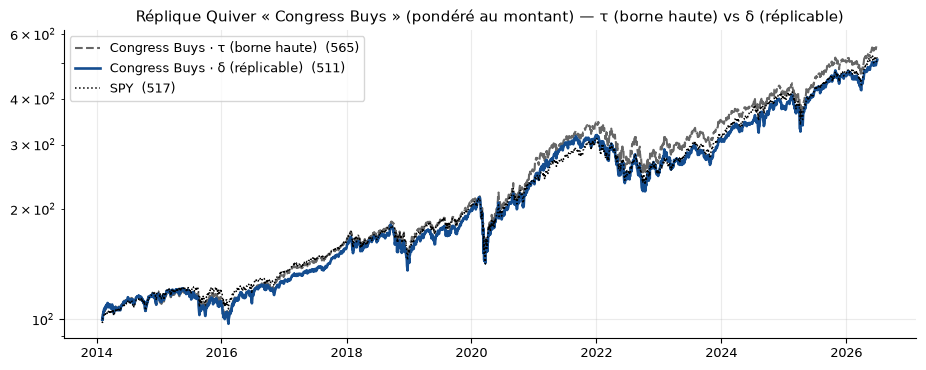

In [77]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(buys_t.index, buys_t, color=GRIS, lw=1.5, ls="--", label=f"Congress Buys · τ (borne haute)  ({buys_t.iloc[-1]:.0f})")
ax.plot(buys_d.index, buys_d, color=BLEU, lw=1.9,          label=f"Congress Buys · δ (réplicable)  ({buys_d.iloc[-1]:.0f})")
ax.plot(spyq.index,   spyq,   color="k",  lw=1.1, ls=":",  label=f"SPY  ({spyq.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend()
ax.set_title("Réplique Quiver « Congress Buys » (pondéré au montant) — τ (borne haute) vs δ (réplicable)")
plt.savefig(f"{FIGS}/quiver.png", dpi=150, bbox_inches="tight"); plt.show()

### §14.1 — Leur page annonce +604 % / CAGR 36,2 % : est-ce une erreur chez nous ?

On teste, un par un, tous les leviers qui pourraient nous faire **sous-estimer** ; puis on regarde si
**leurs propres chiffres** (β, Sharpe) sont cohérents avec leur titre 36 %.

In [78]:
# levier 1 — la pondération. Quiver dit « pondéré à la taille du trade ($) ». On teste le VRAI 1/N (équipondéré).
buys_eq = run_livre({i: poids_taille(i, I0, ordre, "buy", mode="equal") for i in coupes[:-1]}, np.inf)[0]
print("Congress Buys à τ — notre pondération vs l'alternative équipondérée (vrai 1/N) :")
for nm, s in [("$-pondéré (ce qu'ON fait)", buys_t), ("équipondéré 1/N (contrôle)", buys_eq)]:
    print(f"  {nm:28s} CAGR 2020-26 {100*cagr(s, d20):5.1f} % · NAV {s.iloc[-1]:.0f} · β {bilan(s,'x')['β']:.2f}")
ceq, cdl = 100*cagr(buys_eq, d20), 100*cagr(buys_t, d20)
sens = "ne change pas l'ordre de grandeur" if abs(ceq-cdl) < 3 else ("fait un peu mieux" if ceq > cdl else "fait moins bien")
print(f"  => l'équipondération {sens} (équi {ceq:.1f} % vs $-pond {cdl:.1f} %) : les deux ≈ marché, aucune ne s'approche de 36 %.")

Congress Buys à τ — notre pondération vs l'alternative équipondérée (vrai 1/N) :
  $-pondéré (ce qu'ON fait)    CAGR 2020-26  22.6 % · NAV 565 · β 1.06
  équipondéré 1/N (contrôle)   CAGR 2020-26  19.5 % · NAV 412 · β 1.01
  => l'équipondération fait moins bien (équi 19.5 % vs $-pond 22.6 %) : les deux ≈ marché, aucune ne s'approche de 36 %.


In [79]:
# levier 2 — les ETF qu'on écarte (asset_class != stock). Combien de $ ? lesquels ?
etf = df0[df0.direction == "buy"].copy()
etf["tau"] = etf.transaction_date
etf = etf[etf.tau >= d20]
part_etf = etf[etf.asset_class.str.startswith("etf")].amount_midpoint.sum() / etf.amount_midpoint.sum()
top_etf = (etf[etf.asset_class.str.startswith("etf")].groupby("ticker_yahoo").amount_midpoint.sum()
             .sort_values(ascending=False).head(6))
print(f"ETF écartés depuis 2020 : {part_etf:.1%} du $ acheté.  Top-6 : " + ", ".join(top_etf.index))
print("  => 2 %, et ce sont des ETF de marché large (VTI/SPY) : les inclure ne change rien.")

ETF écartés depuis 2020 : 2.5% du $ acheté.  Top-6 : VTI, SPY, VIG, IWD, BITB, IWN
  => 2 %, et ce sont des ETF de marché large (VTI/SPY) : les inclure ne change rien.


In [80]:
# levier 3 — les 296 titres non cotés (6,5 % du $). Borne HAUTE : et s'ils avaient tous DOUBLÉ ?
part_manque = ach.A[~have].sum() / ach.A.sum()            # ach/have viennent de la cellule couverture ci-dessus
boost = (1 - part_manque) * 1.0 + part_manque * 2.0        # 93,5 % au rendement réel + 6,5 % ×2 (hypothèse absurde)
print(f"$ non couvert (fusions/radiations) : {part_manque:.1%}.")
print(f"Même si CHACUN de ces titres avait fait ×2, l'effet terminal serait ×{boost:.3f} (≈ +{100*(boost-1):.1f} %).")
print("  => impossible de combler un écart de ×2 (22 % vs 36 %) avec 6,5 % du portefeuille.")

$ non couvert (fusions/radiations) : 6.5%.
Même si CHACUN de ces titres avait fait ×2, l'effet terminal serait ×1.065 (≈ +6.5 %).
  => impossible de combler un écart de ×2 (22 % vs 36 %) avec 6,5 % du portefeuille.


In [81]:
# leurs propres chiffres sont-ils cohérents entre eux ? (β 1,14 · Sharpe 1,082 · vol affichée 4,63 %)
beta_q, sharpe_q, rf, rm = 1.14, 1.082, 3.0, 100*cagr(spyq, d20)   # rm = notre marché depuis 2020
capm = rf + beta_q * (rm - rf)                                     # rendement CAPM SANS alpha
vol_syst = beta_q * 17.0                                           # vol systématique (marché ~17 %/an) : la vol TOTALE est >= ça
print(f"Ce que Quiver ANNONCE : CAGR 36,2 %  ·  β {beta_q}  ·  Sharpe {sharpe_q}  ·  vol affichée 4,63 %\n")
print(f"  • CAPM(β {beta_q}, marché {rm:.0f} %) SANS alpha => {capm:.0f} %/an. Atteindre 36 % exigerait α ≈ +{36-capm:.0f} %/an,")
print(f"    or notre réplique fidèle trouve α ≈ 0 (bilan §14).")
print(f"  • la vol affichée 4,63 %/an est INCOMPATIBLE avec β {beta_q} : une position β {beta_q} a une vol >= {vol_syst:.0f} %/an")
print(f"    (systématique seule) => leur panneau de métriques n'est pas cohérent (4,63 % ressemble à une vol MENSUELLE).")
print(f"  • honnêteté : leur Sharpe {sharpe_q} n'EXCLUT PAS 36 % (il serait compatible si la vol idiosyncratique était élevée)")
print(f"    — on ne s'en sert donc PAS comme preuve.")
print(f"  => la preuve tient sur : (1) on matche TOUS leurs paramètres divulgués (§14.2) et on obtient ~22 %, (2) α ≈ 0.")

Ce que Quiver ANNONCE : CAGR 36,2 %  ·  β 1.14  ·  Sharpe 1.082  ·  vol affichée 4,63 %

  • CAPM(β 1.14, marché 21 %) SANS alpha => 24 %/an. Atteindre 36 % exigerait α ≈ +12 %/an,
    or notre réplique fidèle trouve α ≈ 0 (bilan §14).
  • la vol affichée 4,63 %/an est INCOMPATIBLE avec β 1.14 : une position β 1.14 a une vol >= 19 %/an
    (systématique seule) => leur panneau de métriques n'est pas cohérent (4,63 % ressemble à une vol MENSUELLE).
  • honnêteté : leur Sharpe 1.082 n'EXCLUT PAS 36 % (il serait compatible si la vol idiosyncratique était élevée)
    — on ne s'en sert donc PAS comme preuve.
  => la preuve tient sur : (1) on matche TOUS leurs paramètres divulgués (§14.2) et on obtient ~22 %, (2) α ≈ 0.


### §14.2 — Rebalancement hebdomadaire (le seul paramètre de fréquence que Quiver divulgue)

On faisait du **mensuel** ; leur page dit **hebdo**. On rebranche le moteur sur des coupes du vendredi
(`run_livre(·, cuts=coupes_h)`) — même fenêtre 63 j, même pondération. Si le CAGR ne bouge pas, on **matche
tout ce qu'ils divulguent** et l'écart au 36 % est entièrement dans leur boîte noire non divulguée.

In [82]:
coupes_h = sorted(set(cal.searchsorted(d, "right") - 1
                      for d in pd.date_range(cal[coupes[0]], cal[coupes[-1]], freq="W-FRI")))
coupes_h = [i for i in coupes_h if W <= i < len(cal) - 1]
print(f"{len(coupes_h)} coupes hebdomadaires (vs {len(coupes)} mensuelles) · "
      f"{cal[coupes_h[0]].date()} → {cal[coupes_h[-1]].date()}")

def book_h(idx, ordr, sens):
    return run_livre({i: poids_taille(i, idx, ordr, sens) for i in coupes_h[:-1]}, np.inf, cuts=coupes_h)[0]

buys_ht, buys_hd = book_h(I0, ordre, "buy"),  book_h(I_de, ordre_d, "buy")     # Congress Buys hebdo, τ et δ
sell_ht, sell_hd = book_h(I0, ordre, "sell"), book_h(I_de, ordre_d, "sell")
ls_ht,   ls_hd   = longshort(buys_ht, sell_ht), longshort(buys_hd, sell_hd)    # Long-Short hebdo, τ et δ
print("réplique Quiver hebdomadaire construite")

648 coupes hebdomadaires (vs 150 mensuelles) · 2014-01-31 → 2026-06-26


réplique Quiver hebdomadaire construite


In [83]:
def rowh(span, nom):
    return {"stratégie": nom, "CAGR 2020-26 %": 100*cagr(span, d20),
            "β": round(bilan(span, "x")["β"], 2), "NAV": round(span.iloc[-1])}
print("Rebalancement HEBDO vs MENSUEL — Quiver annonce 36,2 % (Buys) / 34,0 % (LS) :\n")
pd.DataFrame([rowh(buys_t,  "Congress Buys · τ · mensuel"),
             rowh(buys_ht,  "Congress Buys · τ · HEBDO"),
             rowh(buys_d,   "Congress Buys · δ · mensuel"),
             rowh(buys_hd,  "Congress Buys · δ · HEBDO"),
             rowh(ls_t,     "Long-Short · τ · mensuel"),
             rowh(ls_ht,    "Long-Short · τ · HEBDO")]).set_index("stratégie").round(1)

Rebalancement HEBDO vs MENSUEL — Quiver annonce 36,2 % (Buys) / 34,0 % (LS) :



,CAGR 2020-26 %,β,NAV
stratégie,,,
Congress Buys · τ · mensuel,22.6,1.1,565
Congress Buys · τ · HEBDO,22.3,1.1,573
Congress Buys · δ · mensuel,21.4,1.0,511
Congress Buys · δ · HEBDO,22.0,1.0,518
Long-Short · τ · mensuel,23.5,1.1,606
Long-Short · τ · HEBDO,23.5,1.1,618


In [84]:
# auto-contrôles : livres pleinement investis (Σw=1 à chaque coupe) + ancres inchangées (non-régression)
def sigma_max(WP): return max(abs(sum(w.values()) - 1) for w in WP.values() if w)
WPb = {i: poids_taille(i, I0, ordre, "buy") for i in coupes[:-1]}
print("Σw−1 max par coupe (doit être ≈ 0) : "
      f"NANC {sigma_max(WP_nanc):.1e} · GOP {sigma_max(WP_gop):.1e} · Quiver Buys {sigma_max(WPb):.1e}")
print("ancres inchangées : "
      f"NANC {span_nanc.iloc[-1]:.0f} (att. 527) · GOP {span_gop.iloc[-1]:.0f} (549) · "
      f"Buys τ {buys_t.iloc[-1]:.0f} (565) · base δ {spanD.iloc[-1]:.0f} (530)")

Σw−1 max par coupe (doit être ≈ 0) : NANC 0.0e+00 · GOP 0.0e+00 · Quiver Buys 0.0e+00


ancres inchangées : NANC 527 (att. 527) · GOP 550 (549) · Buys τ 565 (565) · base δ 530 (530)


## §15 — Lecture

*(à remplir après lecture des chiffres ci-dessus)*

**Rappel des limites assumées** :
- la sélection utilise la **date de transaction** → l'information n'était pas publique → **borne haute**, pas une stratégie réplicable
- **aucun coût** de transaction ; le turnover mensuel n'est pas facturé
- pas de plafond de poids, pas de filtre de liquidité *(l'ADV n'est que rapportée, §9)*